# EcoSort Waste Management Assistant
## Module 8 Summative Lab — Neural Networks and Similar Models

EcoSort has partnered with Metro City's waste management department to build an intelligent assistant that helps residents dispose of waste correctly. The assistant:

1. **Identifies waste materials from images** uploaded by residents (CNN with transfer learning)
2. **Classifies waste items from text descriptions** (fine-tuned DistilBERT transformer)
3. **Generates recycling instructions** grounded in city policy (Flan-T5 generator with Retrieval-Augmented Generation)

### Notebook map

| Part | Content |
|---|---|
| 0 | Environment setup and run configuration |
| 1 | Dataset exploration, data-quality checks and data pipelines |
| 2 | CNN image classifier: architecture experiments, class weighting, fine-tuning, error analysis |
| 3 | Text classifier: TF-IDF baseline, DistilBERT experiments, leakage check, challenge set |
| 4 | RAG: section-aware chunking, retrieval benchmark, generator fine-tuning, decoding experiments, grounding safeguards |
| 5 | Integrated assistant: interfaces, error handling, caching, feedback loop, standard and edge-case tests |

> **How to run:** restart the kernel and choose *Run All* so every cell executes in order. The epoch counts in the configuration cell are set for a CPU; lower them if training is too slow.

## Part 0: Environment Setup

### 0.1 Imports

We use:

- **TensorFlow / Keras** for the CNN.
- **Hugging Face Transformers** (TensorFlow classes) for DistilBERT and Flan-T5.
- **sentence-transformers + FAISS** for retrieval.
- **scikit-learn** for splitting, metrics and baselines.

`TF_USE_LEGACY_KERAS=1` must be set **before** TensorFlow is imported. It makes `tf.keras` resolve to Keras 2 (`tf_keras`), which the Hugging Face TensorFlow model classes require.

Required packages: `tensorflow tf-keras transformers sentence-transformers faiss-cpu sentencepiece scikit-learn pandas seaborn pillow`.

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"     # Keras 2 (tf_keras) so Hugging Face TF models work
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"    # hide TensorFlow info/warning logs

import json, re, random, pathlib, warnings, time, unicodedata, math, copy, gc
from collections import Counter, defaultdict
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

import transformers
from transformers import (AutoTokenizer, TFDistilBertForSequenceClassification,
                          T5Tokenizer, TFT5ForConditionalGeneration)
from sentence_transformers import SentenceTransformer
import faiss

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()
tf.get_logger().setLevel("ERROR")
import socket
socket.setdefaulttimeout(600)   # slow networks: allow model downloads to finish

sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__, "| Transformers:", transformers.__version__)

c:\Users\OMokera\.conda\envs\ecosort_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.15.0 | Transformers: 4.57.6


### 0.2 Run Configuration and Reproducibility

Every tunable setting lives in one cell, so experiments are easy to repeat and the grader can see exactly what was used. Fixing the random seeds for NumPy, TensorFlow and Python makes the data splits and weight initialisation repeatable.

In [2]:
SEED = 42
IMG_SIZE = (224, 224)       # input size expected by EfficientNetB0 / MobileNetV2
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# CNN
EXP_EPOCHS = 5              # epochs per architecture experiment (quick comparison)
HEAD_EPOCHS = 20            # max epochs for the chosen head (early stopping applies)
FT_EPOCHS = 10              # max epochs for fine-tuning the top of the base model
FINE_TUNE_LAYERS = 40       # number of top base-model layers to unfreeze

# Text classifier
TEXT_EPOCHS = 3

# RAG generator
GEN_MODEL_NAME = "google/flan-t5-small"
GEN_EPOCHS = 4
N_PER_CAT_FT = 25           # fine-tuning examples per category
MAX_SRC_LEN = 384           # prompt tokens
MAX_TGT_LEN = 128           # answer tokens

def set_seeds(seed=SEED):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

set_seeds()

## Part 1: Dataset Exploration and Preparation

### 1.1 Locate the RealWaste Dataset and Check the Class Distribution

The helper below searches the working directory for the first folder that contains at least five sub-folders of images. This handles datasets that were unzipped into nested folders. We then count images per class.

**Why it matters:** a skewed distribution biases a classifier toward large classes. The imbalance ratio (largest class ÷ smallest class) tells us whether we need class weighting in Part 2.

Dataset root : realwaste
Classes (9): ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images : 4752
Imbalance ratio (largest / smallest): 2.90


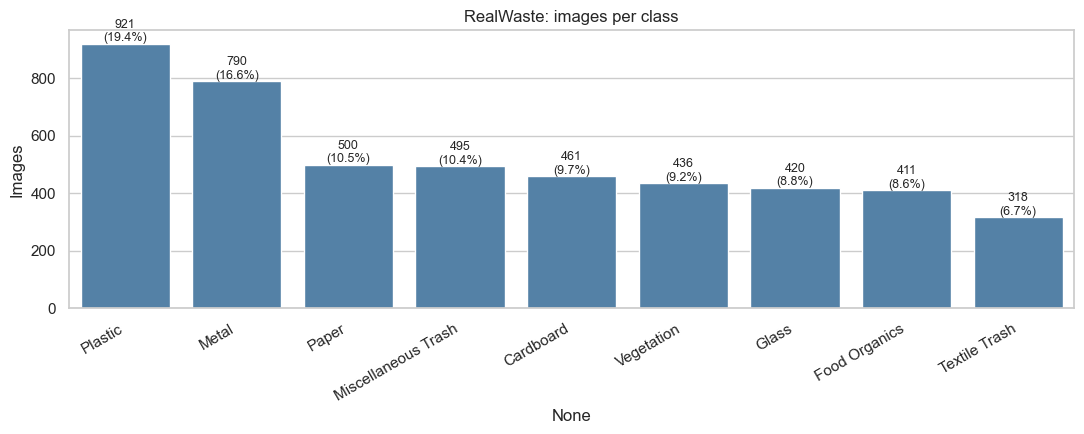

In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png"}

def find_dataset_root(start="."):
    """Return the first folder with >= 5 sub-folders that contain images."""
    start_path = pathlib.Path(start)
    for path in [start_path] + sorted(start_path.rglob("*")):
        if not path.is_dir() or path.name.startswith("."):
            continue
        subdirs = [d for d in path.iterdir() if d.is_dir() and not d.name.startswith(".")]
        if len(subdirs) >= 5 and any(
                any(f.suffix.lower() in IMG_EXTS for f in d.iterdir()) for d in subdirs):
            return path
    return None

def list_images(folder):
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)

data_dir = find_dataset_root(".")
assert data_dir is not None, "RealWaste class folders not found next to the notebook."
data_dir = pathlib.Path(data_dir)

class_names = sorted(d.name for d in data_dir.iterdir()
                     if d.is_dir() and not d.name.startswith("."))
image_files = {c: list_images(data_dir / c) for c in class_names}
counts = pd.Series({c: len(v) for c, v in image_files.items()}).sort_values(ascending=False)

print(f"Dataset root : {data_dir}")
print(f"Classes ({len(class_names)}): {class_names}")
print(f"Total images : {counts.sum()}")
print(f"Imbalance ratio (largest / smallest): {counts.max() / counts.min():.2f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, color="steelblue")
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}\n({v / counts.sum():.1%})", ha="center", fontsize=9)
ax.set_title("RealWaste: images per class")
ax.set_ylabel("Images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 1.2 Visual Inspection: One Sample per Class

Looking at real examples shows what the model must learn. It also reveals how similar some classes look, such as Paper vs. Cardboard, or Plastic vs. Miscellaneous Trash. Each title shows the image resolution.

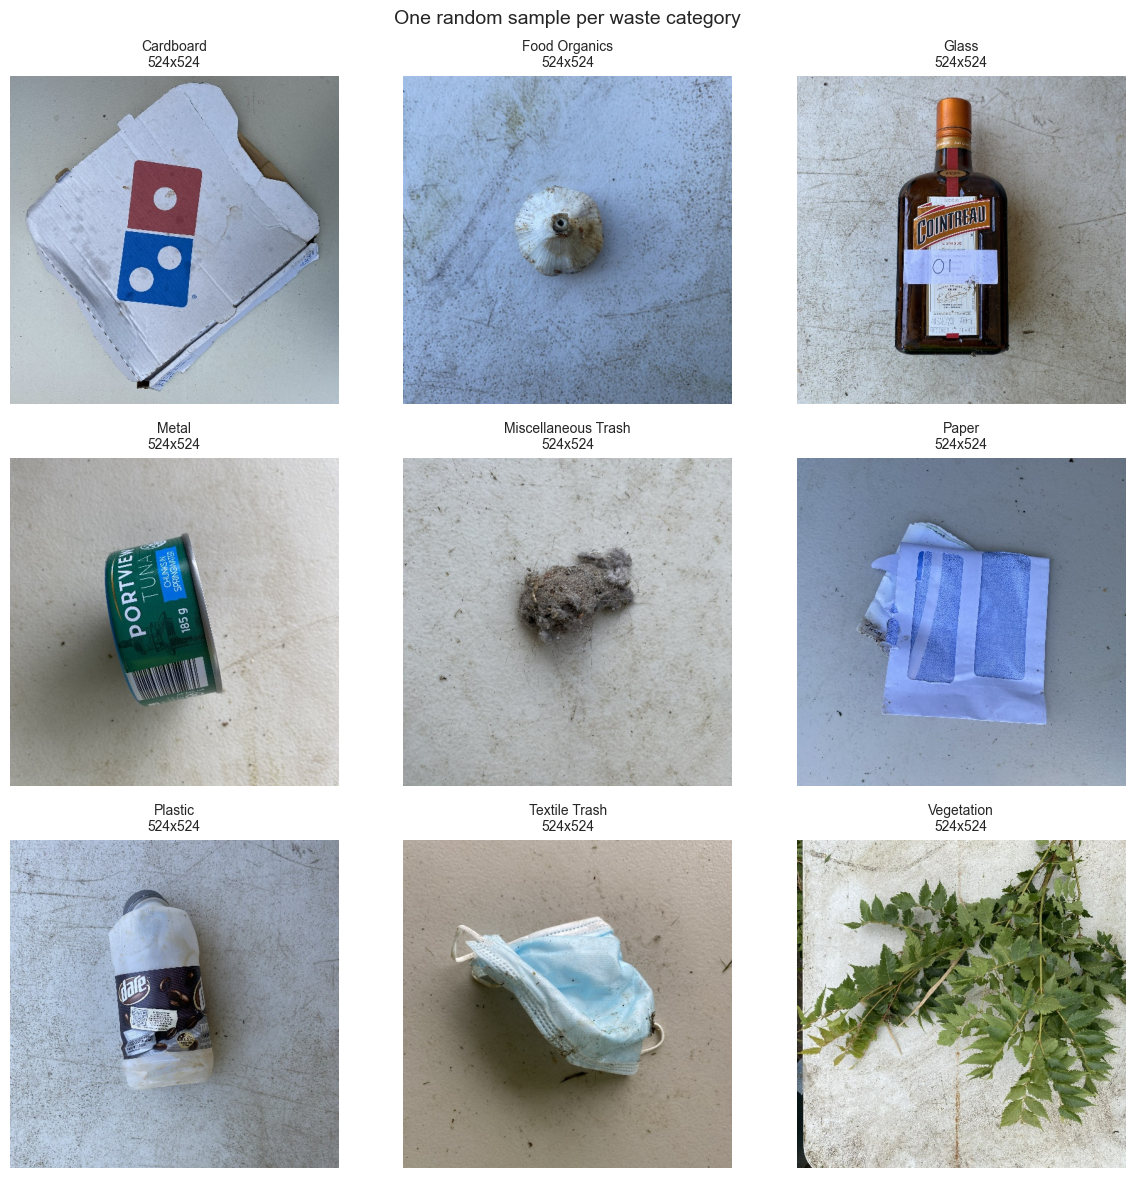

In [4]:
rng = random.Random(SEED)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, c in zip(axes.ravel(), class_names):
    p = rng.choice(image_files[c])
    with Image.open(p) as im:
        ax.imshow(im.convert("RGB"))
        ax.set_title(f"{c}\n{im.size[0]}x{im.size[1]}", fontsize=10)
    ax.axis("off")
plt.suptitle("One random sample per waste category", fontsize=14)
plt.tight_layout()
plt.show()

### 1.3 Image Characteristics, Integrity and Duplicate Check

The brief asks us to analyse resolution, quality and background. We make one pass over **every** image and record:

| Measure | How it's computed | Why it matters |
|---|---|---|
| Resolution, aspect ratio, colour mode | from the file header | Decides the resize strategy and whether distortion occurs |
| Brightness and contrast | mean and std of grayscale pixels | Lighting variation the model must be robust to |
| Sharpness | variance of an edge-filtered image | Low values indicate blurry photos |
| Background brightness and variability | pixels in an 8-px border | If backgrounds differ systematically by class, the CNN may learn a shortcut from the background instead of the object |
| Integrity | `PIL.Image.verify()` | A corrupt file would crash the `tf.data` pipeline |
| Difference hash (dHash) | 16×16 gradient fingerprint | Finds duplicate photos, which would leak between train and test splits |

In [5]:
def inspect_image(path):
    """Collect quality statistics for one image; never raises."""
    try:
        with Image.open(path) as im:
            im.verify()                      # detects truncated / corrupt files
        with Image.open(path) as im:
            w, h, mode, fmt = im.size[0], im.size[1], im.mode, im.format
            g = im.convert("L")
            small = g.resize((128, 128))
            arr = np.asarray(small, dtype=np.float32)
            edges = np.asarray(small.filter(ImageFilter.FIND_EDGES), dtype=np.float32)
            border = np.concatenate([arr[:8].ravel(), arr[-8:].ravel(),
                                     arr[:, :8].ravel(), arr[:, -8:].ravel()])
            d = np.asarray(g.resize((17, 16)), dtype=np.int16)
            dhash = np.packbits((d[:, 1:] > d[:, :-1]).ravel()).tobytes().hex()
        return dict(ok=True, width=w, height=h, mode=mode, format=fmt,
                    aspect=w / h, brightness=arr.mean(), contrast=arr.std(),
                    sharpness=edges.var(), bg_brightness=border.mean(),
                    bg_std=border.std(), dhash=dhash)
    except Exception as e:
        return dict(ok=False, error=str(e))

t0 = time.time()
rows = []
for c in class_names:
    for p in image_files[c]:
        rows.append({"path": str(p), "category": c, **inspect_image(p)})
img_meta = pd.DataFrame(rows)
print(f"Inspected {len(img_meta)} images in {time.time() - t0:.0f}s")

bad = img_meta[~img_meta["ok"]]
print(f"Unreadable / corrupt images: {len(bad)}")
if len(bad):
    display(bad[["path", "error"]].head())

good = img_meta[img_meta["ok"]].copy()
print("\nMost common resolutions:")
print(good.groupby(["width", "height"]).size().sort_values(ascending=False).head(5).to_string())
print("\nColour modes:", good["mode"].value_counts().to_dict())
print("File formats:", good["format"].value_counts().to_dict())
print(f"Aspect ratio range: {good['aspect'].min():.2f} - {good['aspect'].max():.2f}")

Inspected 4752 images in 49s
Unreadable / corrupt images: 0

Most common resolutions:
width  height
524    524       4752

Colour modes: {'RGB': 4752}
File formats: {'JPEG': 4752}
Aspect ratio range: 1.00 - 1.00


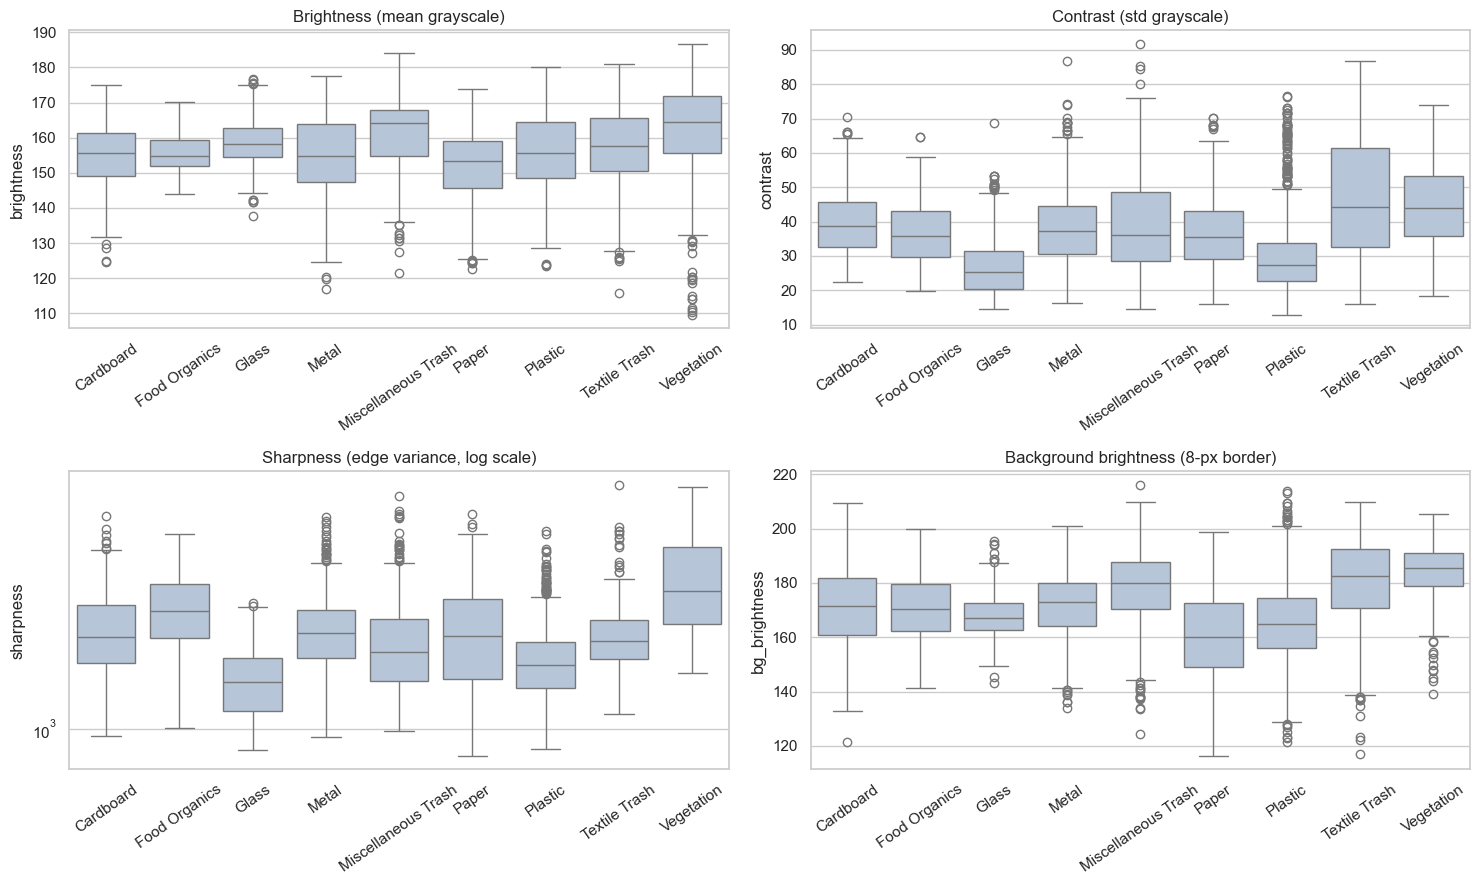

,brightness,contrast,sharpness,bg_brightness,bg_std
category,,,,,
Cardboard,155.800003,38.700001,2128.000000,171.699997,22.900000
Food Organics,154.800003,35.900002,2628.500000,170.300003,21.500000
Glass,158.199997,25.299999,1464.099976,167.199997,20.900000
Metal,154.800003,37.299999,2185.600098,173.100006,17.500000
Miscellaneous Trash,164.199997,36.000000,1872.000000,179.899994,16.700001
Paper,153.300003,35.400002,2138.600098,160.000000,20.400000
Plastic,155.500000,27.400000,1683.599976,164.800003,18.299999
Textile Trash,157.699997,44.299999,2055.800049,182.600006,16.400000
Vegetation,164.399994,44.000000,3103.100098,185.500000,22.000000


Images below the 2nd sharpness percentile (possible blur): 96


In [6]:
# Per-class quality statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (col, title) in zip(axes.ravel(), [
        ("brightness", "Brightness (mean grayscale)"),
        ("contrast", "Contrast (std grayscale)"),
        ("sharpness", "Sharpness (edge variance, log scale)"),
        ("bg_brightness", "Background brightness (8-px border)")]):
    sns.boxplot(data=good, x="category", y=col, ax=ax, color="lightsteelblue")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    if col == "sharpness":
        ax.set_yscale("log")
plt.tight_layout()
plt.show()

summary = good.groupby("category")[["brightness", "contrast", "sharpness",
                                    "bg_brightness", "bg_std"]].median().round(1)
display(summary)

# Flag blurry outliers (bottom 2% sharpness)
blur_cut = good["sharpness"].quantile(0.02)
print(f"Images below the 2nd sharpness percentile (possible blur): {(good['sharpness'] < blur_cut).sum()}")

In [7]:
# Duplicate detection with the difference hash
dup_groups = good[good.duplicated("dhash", keep=False)].groupby("dhash")
n_groups = dup_groups.ngroups
cross_class = [g for _, g in dup_groups if g["category"].nunique() > 1]
print(f"Duplicate groups (identical dHash): {n_groups}")
print(f"Images that are extra copies     : {good.duplicated('dhash').sum()}")
print(f"Groups spanning different classes (label noise): {len(cross_class)}")

# Show up to 3 duplicate pairs for visual confirmation
shown = [g for _, g in dup_groups][:3]
if shown:
    fig, axes = plt.subplots(len(shown), 2, figsize=(7, 3.2 * len(shown)), squeeze=False)
    for r, g in enumerate(shown):
        for k in range(2):
            row = g.iloc[k]
            with Image.open(row["path"]) as im:
                axes[r, k].imshow(im.convert("RGB"))
            axes[r, k].set_title(f"{row['category']}\n{pathlib.Path(row['path']).name}", fontsize=8)
            axes[r, k].axis("off")
    plt.tight_layout()
    plt.show()

# Clean file list: readable images only, first copy of each duplicate
clean_meta = good.drop_duplicates("dhash", keep="first").reset_index(drop=True)
print(f"Images kept for modelling: {len(clean_meta)} (removed {len(img_meta) - len(clean_meta)})")

Duplicate groups (identical dHash): 0
Images that are extra copies     : 0
Groups spanning different classes (label noise): 0
Images kept for modelling: 4752 (removed 0)


#### Image dataset: observations, challenges and limitations

- **Integrity and format.** All 4,752 images are readable RGB JPEGs, and every one is **524×524** (aspect ratio 1.00). Resizing to 224×224 is therefore a uniform downscale with no stretching or cropping.
- **Duplicates.** The difference-hash check found no duplicate groups, so no images were removed and there is no duplicate leakage between splits. dHash only catches near-identical photos, so re-photographed items could still exist.
- **Class imbalance.** Plastic (921 images, 19.4%) and Metal (790) dominate, and Textile Trash is smallest (318). The imbalance ratio is **2.90**. Class weights in Part 2 range from 0.57 (Plastic) to 1.67 (Textile Trash).
- **Background.** Median border brightness is similar across classes (160 for Paper to 186 for Vegetation, border std 16–23). The model is therefore unlikely to learn a background shortcut and must rely on the object itself. Vegetation and Textile Trash have slightly brighter borders, so this is a small residual risk.
- **Hard materials.** Glass (contrast 25.3, sharpness 1,464) and Plastic (27.4, 1,684) have the **lowest contrast and sharpness** of all classes. Transparent and reflective materials lack strong edges. This predicts the Plastic↔Glass confusion seen in Part 2. Vegetation is the sharpest class (3,103), because leaves and branches are highly textured.
- **Blur.** 96 images fall below the 2nd sharpness percentile. They were kept, because residents' uploads will include blurry photos too.
- **Bias.** All images come from one waste facility with a consistent camera setup. Residents' phone photos (kitchen counters, hands in frame, different lighting) are out of distribution, so real-world accuracy will likely be lower than test accuracy.

### 1.4 Explore the Waste Description Text Data

We check:

- the schema, missing values and any extra columns;
- **duplicates and conflicting labels**, which cause leakage and noise;
- the category balance and description lengths;
- **vocabulary**: overall size, the most frequent words, the most distinctive words per category, and generic modifier words that appear in almost every category and so carry no signal;
- the disposal instructions available per category, which feed the RAG corpus in Part 4.

In [8]:
desc_df = pd.read_csv("waste_descriptions.csv")
print("Shape:", desc_df.shape)
print("Columns:", list(desc_df.columns))
print("\nMissing values per column:")
print(desc_df.isna().sum().to_string())
display(desc_df.head(8))

# Inspect any extra columns (e.g., confusion cases, material composition, regional terms)
core_cols = {"description", "category", "disposal_instruction"}
for col in [c for c in desc_df.columns if c not in core_cols]:
    print(f"\nColumn '{col}': {desc_df[col].nunique()} unique values. Most common:")
    print(desc_df[col].value_counts().head(5).to_string())

Shape: (5000, 5)
Columns: ['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

Missing values per column:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0


,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
5,wrinkled pink takeout container with product r...,Plastic,Remove labels if possible.,Plastic bags often can not go in general recyc...,Polymer materials derived from petrochemicals ...
6,broken glass container,Glass,"Remove caps, lids, and corks before recycling.","Window glass, drinking glasses, and ceramics s...","Silica-based material, may contain additives f..."
7,clean red grass clippings,Vegetation,Large branches may need to be cut to appropria...,NaN,Plant matter composed primarily of cellulose a...



Column 'common_confusion': 9 unique values. Most common:
common_confusion
Invasive species may require special disposal. Large branches might need separate collection.           315
Some textiles can be recycled or donated, even if worn or torn.                                         305
Plastic bags often can not go in general recycling. Check for recycling numbers (1-7) on containers.    291
Window glass, drinking glasses, and ceramics should not go in container glass recycling.                283
Pizza boxes with food stains should go in organic waste or general trash, not recycling.                271

Column 'material_composition': 9 unique values. Most common:
material_composition
Plant matter composed primarily of cellulose and lignin.                 600
Fabric made from natural or synthetic fibers, may include blends.        586
Thick paper pulp formed into corrugated or solid sheets.                 584
Various non-recyclable materials often with mixed composition.         

Duplicate descriptions (case-insensitive): 61 (1.2%)
Descriptions labelled with more than one category: 0


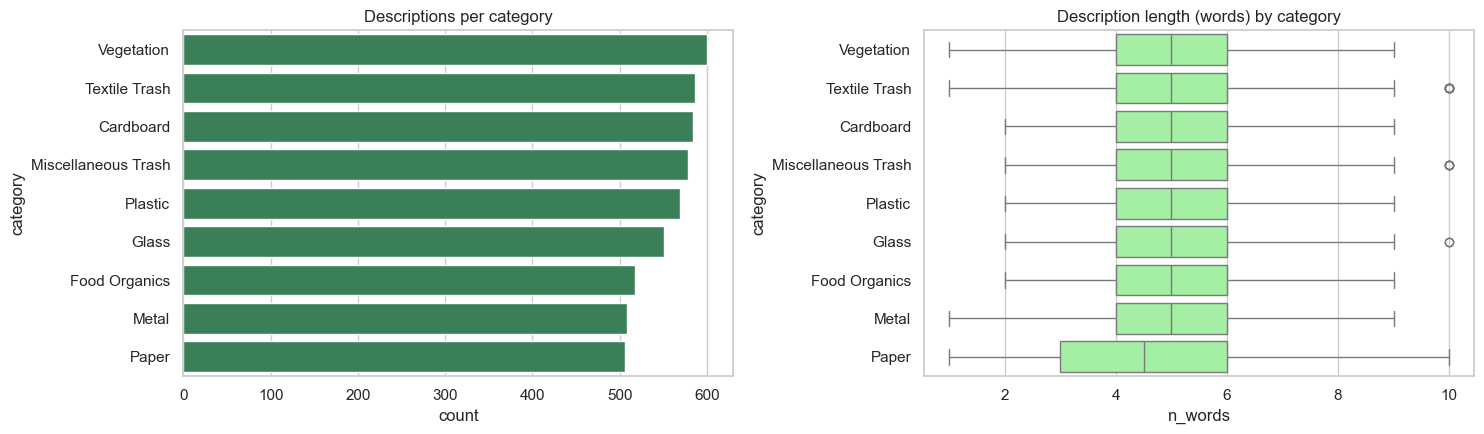

count    5000.00
mean        4.85
std         1.55
min         1.00
25%         4.00
50%         5.00
75%         6.00
max        10.00


In [9]:
# Duplicates and conflicting labels
norm_desc = desc_df["description"].str.lower().str.strip()
n_dup = norm_desc.duplicated().sum()
labels_per_text = desc_df.assign(n=norm_desc).groupby("n")["category"].nunique()
n_conflict = int((labels_per_text > 1).sum())
print(f"Duplicate descriptions (case-insensitive): {n_dup} ({n_dup / len(desc_df):.1%})")
print(f"Descriptions labelled with more than one category: {n_conflict}")
if n_conflict:
    ex = labels_per_text[labels_per_text > 1].index[:5]
    display(desc_df[norm_desc.isin(ex)].sort_values("description")[["description", "category"]])

# Category balance and length by category
desc_df["n_words"] = desc_df["description"].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
order = desc_df["category"].value_counts().index
sns.countplot(data=desc_df, y="category", order=order, ax=axes[0], color="seagreen")
axes[0].set_title("Descriptions per category")
sns.boxplot(data=desc_df, y="category", x="n_words", order=order, ax=axes[1], color="palegreen")
axes[1].set_title("Description length (words) by category")
plt.tight_layout()
plt.show()
print(desc_df["n_words"].describe().round(2).to_string())

In [10]:
# Vocabulary analysis
def simple_tokens(s):
    return re.findall(r"[a-z0-9#]+(?:-[a-z0-9]+)*", str(s).lower())

vocab = Counter(t for s in desc_df["description"] for t in simple_tokens(s))
print(f"Vocabulary size: {len(vocab)} unique tokens | total tokens: {sum(vocab.values())}")
print("Top 20 tokens:", vocab.most_common(20))

# Distinctive words per category: TF-IDF over one 'document' per category
cat_docs = desc_df.groupby("category")["description"].apply(" ".join)
cat_tfidf = TfidfVectorizer(stop_words="english", token_pattern=r"[a-z][a-z\-]+")
M = cat_tfidf.fit_transform(cat_docs.values)
terms = np.array(cat_tfidf.get_feature_names_out())
distinct = {c: ", ".join(terms[np.argsort(-M[i].toarray().ravel())[:10]])
            for i, c in enumerate(cat_docs.index)}
display(pd.DataFrame.from_dict(distinct, orient="index", columns=["Most distinctive words"]))

# Generic modifiers: words that appear in >= 7 of the 9 categories
cats_per_word = defaultdict(set)
for d, c in zip(desc_df["description"], desc_df["category"]):
    for t in set(simple_tokens(d)):
        cats_per_word[t].add(c)
generic = sorted([w for w, cs in cats_per_word.items() if len(cs) >= 7],
                 key=lambda w: -vocab[w])
print(f"\nGeneric words shared by >= 7 categories ({len(generic)}):", generic[:30])

Vocabulary size: 305 unique tokens | total tokens: 24308
Top 20 tokens: [('with', 727), ('glass', 424), ('empty', 348), ('bottle', 342), ('food', 316), ('paper', 316), ('box', 313), ('residue', 309), ('plastic', 251), ('brand', 247), ('metal', 241), ('dry', 211), ('new', 196), ('soiled', 189), ('crumpled', 189), ('medium', 187), ('orange', 186), ('stained', 185), ('intact', 184), ('broken', 184)]


,Most distinctive words
Cardboard,"box, cardboard, packaging, toilet, roll, gift,..."
Food Organics,"peel, shells, scraps, bones, pit, avocado, spo..."
Glass,"glass, bottle, light, bulb, ornament, perfume,..."
Metal,"metal, hanger, wire, tin, steel, aluminum, foi..."
Miscellaneous Trash,"vacuum, disposable, ceramic, rubber, tape, dvd..."
Paper,"paper, notebook, envelope, paperback, book, ne..."
Plastic,"plastic, bottle, wrap, container, clamshell, b..."
Textile Trash,"fabric, cotton, cloth, linen, carpet, sweater,..."
Vegetation,"plant, trimmings, leaves, tree, clippings, wee..."



Generic words shared by >= 7 categories (84): ['with', 'empty', 'food', 'residue', 'brand', 'dry', 'new', 'soiled', 'crumpled', 'medium', 'orange', 'stained', 'intact', 'broken', 'patterned', 'wrinkled', 'wet', 'torn', 'partial', 'brown', 'partially', 'filled', 'ripped', 'fun-sized', 'travel-sized', 'regular-sized', 'enormous', 'white', 'oversized', 'clean']


In [11]:
# Disposal instructions available per category (used later as RAG documents)
instr = desc_df.groupby("category")["disposal_instruction"].agg(["nunique", lambda s: s.unique()[:3]])
instr.columns = ["n_unique_instructions", "examples"]
display(instr)

,n_unique_instructions,examples
category,,
Cardboard,5,"[If contaminated with food, tear off contamina..."
Food Organics,5,"[If no compost available, place in general was..."
Glass,5,"[Remove caps, lids, and corks before recycling..."
Metal,5,"[For aerosol cans, ensure they are completely ..."
Miscellaneous Trash,5,[Hazardous items like batteries require specia...
Paper,5,[Remove any plastic or metal attachments befor...
Plastic,5,"[Remove labels if possible., Plastic bags can ..."
Textile Trash,5,[Look for textile recycling programs in your a...
Vegetation,5,[Large branches may need to be cut to appropri...


#### Text dataset: observations

- **Schema.** The file has 5,000 rows and 5 columns. `material_composition` has 9 unique values and `common_confusion` has 9 unique values (with 2,504 missing), which is about one fixed sentence per category. **These columns are category-level constants, so using them as classifier features would leak the label.** They are used only as retrieval knowledge: common confusions are added to the RAG corpus in 1.6.3.
- **Structure and vocabulary.** Descriptions are very short (mean 4.85 words, range 1–10) and use a **vocabulary of only 305 unique tokens**. They follow a template, *[modifiers] + [object]*. 84 generic modifiers ("empty", "soiled", "crumpled", "fun-sized"…) appear in at least 7 of the 9 categories, so the **object noun** carries almost all the signal. The distinctive-word table confirms this (box/cardboard, peel/shells, bottle/bulb, hanger/tin…).
- **Duplicates.** There are 61 case-insensitive duplicates (1.2%) and no conflicting labels. Removing them leaves 4,939 rows, so no phrase appears in both train and test.
- **Consequence.** Such a small, templated vocabulary makes near-perfect accuracy likely without proving real-world understanding. Part 3 therefore adds a near-duplicate check and a realistic challenge set.
- **Disposal instructions.** Each category has exactly 5 unique disposal sentences. These become the resident disposal chunks in the RAG corpus.

### 1.5 Explore the Policy Documents

We examine each policy's type, covered categories, effective date and length, and extract its **section headings** (lines ending in `:`). The headings reveal a consistent structure: *Acceptable Items, Non-Acceptable Items, Collection Method, Preparation Instructions, Benefits*. Part 1.6 uses that structure to chunk documents into meaningful sections instead of arbitrary word windows.

In [12]:
with open("waste_policy_documents.json") as f:
    policies = json.load(f)

policy_df = pd.DataFrame(policies)
policy_df["n_words"] = policy_df["document_text"].str.split().str.len()
policy_df["n_categories"] = policy_df["categories_covered"].apply(len)
print(f"Policy documents: {len(policy_df)} | keys: {list(policies[0].keys())}")
display(policy_df[["policy_id", "policy_type", "categories_covered", "effective_date",
                   "jurisdiction", "n_words"]].sort_values("effective_date"))

heading_counts = Counter(
    line.strip()[:-1] for t in policy_df["document_text"]
    for line in t.splitlines() if line.strip().endswith(":"))
print("\nSection headings across all policies:")
print(pd.Series(heading_counts).sort_values(ascending=False).to_string())

covered = Counter(c for cats in policy_df["categories_covered"] for c in cats)
missing = [c for c in class_names if c not in covered]
print("\nPolicy coverage per image class:", {c: covered.get(c, 0) for c in class_names})
print("Classes with no dedicated policy:", missing or "none")
print("\nExample document:\n", policies[0]["document_text"][:600])

Policy documents: 14 | keys: ['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction']


,policy_id,policy_type,categories_covered,effective_date,jurisdiction,n_words
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01,Metro City,97
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,Metro City,86
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,Metro City,94
11,12,Commercial Recycling Standards,"[Food Organics, Metal, Miscellaneous Trash]",2023-05-05,Metro City,102
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,Metro City,98
10,11,Residential Recycling Rules,"[Plastic, Metal, Glass, Miscellaneous Trash, V...",2023-05-26,Metro City,146
12,13,Multi-Unit Building Guidelines,"[Cardboard, Glass, Textile Trash]",2023-07-04,Metro City,100
6,7,Metal Recycling Guidelines,[Metal],2023-09-03,Metro City,102
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01,Metro City,100
7,8,Paper Recycling Guidelines,[Paper],2023-10-14,Metro City,95



Section headings across all policies:
Benefits                          9
Acceptable Items                  8
Non-Acceptable Items              8
Collection Method                 8
Preparation Instructions          8
GENERAL REQUIREMENTS              5
MISCELLANEOUS TRASH GUIDELINES    3
VEGETATION GUIDELINES             3
METAL GUIDELINES                  3
PLASTIC GUIDELINES                2
GLASS GUIDELINES                  2
CARDBOARD GUIDELINES              2
TEXTILE TRASH GUIDELINES          2
Special Handling Items            1
Waste Reduction Tips              1
Items That Cannot Be Recycled     1
FOOD ORGANICS GUIDELINES          1

Policy coverage per image class: {'Cardboard': 3, 'Food Organics': 2, 'Glass': 3, 'Metal': 4, 'Miscellaneous Trash': 4, 'Paper': 1, 'Plastic': 3, 'Textile Trash': 3, 'Vegetation': 4}
Classes with no dedicated policy: none

Example document:
 TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and li

#### Policy documents: observations

- The documents are short, formal and consistently structured, using headings followed by bullet lists. Section-level chunks are therefore natural retrieval units: a question about *how to prepare* an item should retrieve the *Preparation Instructions* section.
- Some policies may cover several categories, or none of the image classes (for example penalties or general rules). These are tagged as **General** so they can be retrieved for any category.
- Classes without a dedicated policy rely on the resident disposal instructions from the CSV. This is another reason to add those instructions to the corpus.
- The small corpus limits what a generator can say, but it makes factual grounding easy to verify.

### 1.6 Data Pipelines and Splits

#### 1.6.1 Image pipeline: stratified 70 / 15 / 15 split on file paths

The original notebook carved the test set out of the validation set with `take()` and `skip()`. That approach is unsafe because `image_dataset_from_directory` **reshuffles on every pass**. The same image can land in both validation and test, and labels collected in a separate loop no longer line up with the predictions.

We instead split the **file paths** with `train_test_split(stratify=...)`, which:

- preserves the class proportions in every split;
- fixes each split permanently, so there is no overlap between them;
- lets us keep the test file paths for Part 5, where the brief asks us to test with a test-set image.

**Preprocessing:** decode the image, force 3 channels (some PNGs have an alpha channel), and resize to 224×224. **Pixels stay in the 0–255 range**, because Keras' EfficientNetB0 contains its own rescaling and normalisation layers. Dividing by 255 beforehand, as the original notebook did, feeds the network near-black images, which is why that model never learned. Only the training set is shuffled; validation and test keep a fixed order so predictions align with labels.

In [13]:
all_paths = clean_meta["path"].tolist()
all_labels = clean_meta["category"].map({c: i for i, c in enumerate(class_names)}).tolist()

train_p, temp_p, train_y, temp_y = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
val_p, test_p, val_y, test_y = train_test_split(
    temp_p, temp_y, test_size=0.50, stratify=temp_y, random_state=SEED)

assert not (set(train_p) & set(val_p) or set(train_p) & set(test_p) or set(val_p) & set(test_p))

split_table = pd.DataFrame({
    "train": pd.Series(train_y).map(dict(enumerate(class_names))).value_counts(),
    "val": pd.Series(val_y).map(dict(enumerate(class_names))).value_counts(),
    "test": pd.Series(test_y).map(dict(enumerate(class_names))).value_counts(),
}).loc[class_names]
split_table.loc["TOTAL"] = split_table.sum()
display(split_table)

def load_image(path, label):
    """Read -> decode (3 channels) -> resize. Output float32 in [0, 255]."""
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img.set_shape((*IMG_SIZE, 3))
    return img, label

def make_image_ds(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((list(paths), list(labels)))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_image_ds(train_p, train_y, training=True)
val_ds = make_image_ds(val_p, val_y, training=False)
test_ds = make_image_ds(test_p, test_y, training=False)

xb, yb = next(iter(train_ds))
print("Batch shape:", xb.shape, "| pixel range:", float(tf.reduce_min(xb)), "-", float(tf.reduce_max(xb)))

,train,val,test
Cardboard,323,69,69
Food Organics,288,61,62
Glass,294,63,63
Metal,553,119,118
Miscellaneous Trash,346,74,75
Paper,350,75,75
Plastic,645,138,138
Textile Trash,222,48,48
Vegetation,305,66,65
TOTAL,3326,713,713


Batch shape: (32, 224, 224, 3) | pixel range: 0.0 - 255.0


#### 1.6.2 Text pipeline: normalisation, de-duplication, stratified 70 / 15 / 15 split

The normalisation is deliberately **light**, because DistilBERT's WordPiece tokenizer is trained on natural text:

- Unicode NFKC normalisation, lowercasing and whitespace collapsing;
- **keep** digits, `#`, hyphens and `/`, so resin codes such as "#1 PET" and compounds such as "fun-sized" survive (the original cleaning deleted them);
- drop exact duplicates and conflicting labels **before** splitting, so no phrase appears in both train and test.

A separate validation set is used for model selection, so the test set is touched only once, for the final evaluation.

In [14]:
def normalize_text(t):
    t = unicodedata.normalize("NFKC", str(t)).lower()
    t = re.sub(r"[^\w\s#\-/%.]", " ", t)      # remove odd symbols, keep resin codes & hyphens
    t = re.sub(r"\s+", " ", t).strip()
    return t

text_df = desc_df.copy()
text_df["text"] = text_df["description"].map(normalize_text)
conflicting = text_df.groupby("text")["category"].transform("nunique") > 1
before = len(text_df)
text_df = text_df[~conflicting].drop_duplicates("text").reset_index(drop=True)
print(f"Rows: {before} -> {len(text_df)} after removing duplicates/conflicts")

text_label_names = sorted(text_df["category"].unique())
if set(text_label_names) != set(class_names):
    print("WARNING: text categories differ from image classes:",
          set(text_label_names) ^ set(class_names))
label2id = {c: i for i, c in enumerate(text_label_names)}
id2label = {i: c for c, i in label2id.items()}
text_df["label"] = text_df["category"].map(label2id)

train_df_text, temp_df = train_test_split(text_df, test_size=0.30,
                                          stratify=text_df["category"], random_state=SEED)
val_df_text, test_df_text = train_test_split(temp_df, test_size=0.50,
                                             stratify=temp_df["category"], random_state=SEED)
X_train_text, y_train_text = train_df_text["text"].tolist(), train_df_text["label"].values
X_val_text, y_val_text = val_df_text["text"].tolist(), val_df_text["label"].values
X_test_text, y_test_text = test_df_text["text"].tolist(), test_df_text["label"].values

assert not set(X_train_text) & set(X_test_text), "train/test overlap"
print(f"Train {len(X_train_text)} | Val {len(X_val_text)} | Test {len(X_test_text)}")
print("Example:", desc_df['description'].iloc[4], "->", normalize_text(desc_df['description'].iloc[4]))

Rows: 5000 -> 4939 after removing duplicates/conflicts
Train 3457 | Val 741 | Test 741
Example: empty fun-sized purple apple core -> empty fun-sized purple apple core


#### 1.6.3 RAG document preparation: section-aware chunking plus disposal instructions and common confusions

The original 200-word chunking produced exactly one chunk per document, so nothing was actually chunked. We now:

1. **Split each policy on its blank-line-separated sections.** Each section becomes one chunk, prefixed with the document title for context. Bullets are joined into a single sentence ("Preparation Instructions: rinse containers; remove caps; ..."). Any section longer than 120 words is split into overlapping windows.
2. **Tag chunks at section level.** Multi-category policies such as *Residential Recycling Rules* contain per-material sections ("METAL GUIDELINES:", "PLASTIC GUIDELINES:"). A section whose heading names a category is tagged with **only that category**. Other sections inherit all the categories the document covers, and policies covering none of the image classes are tagged **General**. Without this, a Plastic query could retrieve a Metal section as if it were Plastic policy.
3. **Add one "Resident disposal instructions" chunk per category**, built from the CSV's `disposal_instruction` column, as the brief requires.
4. **Add one "Common confusions" chunk per category** from the CSV's `common_confusion` column. Examples are "Pizza boxes with food stains should go in organic waste…" and "Plastic bags often can not go in general recycling…". These are exactly the edge cases residents ask about.

Each chunk stores metadata (source, section, effective date, categories), which enables category filtering and source citation.

In [15]:
CATEGORY_SET = set(class_names)
CATEGORY_LOOKUP = {c.lower(): c for c in class_names}

def block_to_section(block):
    """Turn 'Heading:\n- a\n- b' into ('Heading', 'Heading: a; b.')."""
    lines = [l.strip() for l in block.splitlines() if l.strip()]
    head, items = lines[0], lines[1:]
    if head.endswith(":") and items:
        items = [re.sub(r"^[-\u2022*]\s*", "", l) for l in items]
        body = f"{head} " + "; ".join(i.rstrip(".;") for i in items) + "."
        return head[:-1].strip(), body
    return "Overview", " ".join(lines)

def window_words(text, size=120, overlap=20):
    words = text.split()
    if len(words) <= size:
        return [text]
    step = size - overlap
    return [" ".join(words[i:i + size]) for i in range(0, len(words) - overlap, step)]

rag_chunks = []
for p in policies:
    cats = [CATEGORY_LOOKUP[c.lower()] for c in p.get("categories_covered", [])
            if c.lower() in CATEGORY_LOOKUP] or ["General"]
    blocks = [b.strip() for b in re.split(r"\n\s*\n", p.get("document_text", "")) if b.strip()]
    if not blocks:
        continue
    title = blocks[0].splitlines()[0].strip()
    first_rest = "\n".join(blocks[0].splitlines()[1:]).strip()
    blocks = ([first_rest] if first_rest else []) + blocks[1:]
    for block in blocks:
        section, body = block_to_section(block)
        # Section-level tags: a heading such as "METAL GUIDELINES" in a multi-category
        # policy belongs only to Metal, not to every category the document covers.
        named = [c for c in class_names if c.upper() in section.upper()]
        sec_cats = named or cats
        for piece in window_words(body):
            rag_chunks.append(dict(
                id=len(rag_chunks), doc_type="policy", policy_id=p.get("policy_id"),
                source=p.get("policy_type", title), title=title, section=section,
                body=piece, text=f"{title} - {piece}", categories=sec_cats,
                effective_date=p.get("effective_date", "")))

for c in class_names:
    uniq = desc_df.loc[desc_df["category"] == c, "disposal_instruction"].dropna().unique()
    if len(uniq) == 0:
        continue
    body = f"Resident disposal instructions for {c}: " + " ".join(
        u.strip().rstrip(".") + "." for u in uniq)
    for piece in window_words(body):
        rag_chunks.append(dict(
            id=len(rag_chunks), doc_type="disposal", policy_id=None,
            source=f"{c} Resident Disposal Instructions", title=f"{c} disposal instructions",
            section="Resident disposal instructions", body=piece, text=piece,
            categories=[c], effective_date=""))

# Common confusion cases from the CSV (e.g. greasy pizza boxes, plastic bags)
if "common_confusion" in desc_df.columns:
    for c in class_names:
        conf = desc_df.loc[desc_df["category"] == c, "common_confusion"].dropna().unique()
        if len(conf) == 0:
            continue
        body = f"Common confusions for {c}: " + " ".join(u.strip() for u in conf)
        for piece in window_words(body):
            rag_chunks.append(dict(
                id=len(rag_chunks), doc_type="confusion", policy_id=None,
                source=f"{c} Common Confusions", title=f"{c} common confusions",
                section="Common confusions", body=piece, text=piece,
                categories=[c], effective_date=""))

chunk_df = pd.DataFrame(rag_chunks)
print(f"RAG chunks: {len(rag_chunks)} | by type: {chunk_df['doc_type'].value_counts().to_dict()}")
print(f"Policy sections re-tagged to a single named category: "
      f"{sum(1 for c in rag_chunks if c['doc_type'] == 'policy' and len(c['categories']) == 1 and c['section'].upper().endswith('GUIDELINES'))}")
cat_chunk_counts = Counter(c for cs in chunk_df["categories"] for c in cs)
print("Chunks per category:", dict(cat_chunk_counts))
display(chunk_df[["source", "section", "categories", "body"]].head(8))

RAG chunks: 85 | by type: {'policy': 67, 'disposal': 9, 'confusion': 9}
Policy sections re-tagged to a single named category: 18
Chunks per category: {'Textile Trash': 11, 'Glass': 11, 'Food Organics': 9, 'Plastic': 11, 'Vegetation': 13, 'Cardboard': 11, 'Metal': 13, 'Paper': 7, 'Miscellaneous Trash': 12}


,source,section,categories,body
0,Textile Trash Recycling Guidelines,Acceptable Items,[Textile Trash],Acceptable Items: Clean clothing (all conditio...
1,Textile Trash Recycling Guidelines,Non-Acceptable Items,[Textile Trash],Non-Acceptable Items: Wet or moldy textiles; H...
2,Textile Trash Recycling Guidelines,Collection Method,[Textile Trash],Collection Method: Place items in dedicated te...
3,Textile Trash Recycling Guidelines,Preparation Instructions,[Textile Trash],Preparation Instructions: Ensure all items are...
4,Textile Trash Recycling Guidelines,Benefits,[Textile Trash],Benefits: Textile recycling conserves resource...
5,Glass Recycling Guidelines,Acceptable Items,[Glass],Acceptable Items: Glass bottles (all colors); ...
6,Glass Recycling Guidelines,Non-Acceptable Items,[Glass],Non-Acceptable Items: Window glass or mirrors;...
7,Glass Recycling Guidelines,Collection Method,[Glass],Collection Method: Place in dedicated glass re...


## Part 2: Waste Material Classification with CNN

### 2.1 Data Augmentation

Augmentation creates realistic variations of the training images: flips, rotations, zooms and contrast changes that mimic how residents photograph items. It works as a regulariser, so the model cannot memorise exact pixels.

The augmentation layers sit **inside the model**. Keras applies them only during training and turns them off automatically for validation, testing and inference. The original notebook defined an augmentation pipeline but never used it.

The cell below shows six augmented versions of one training image.

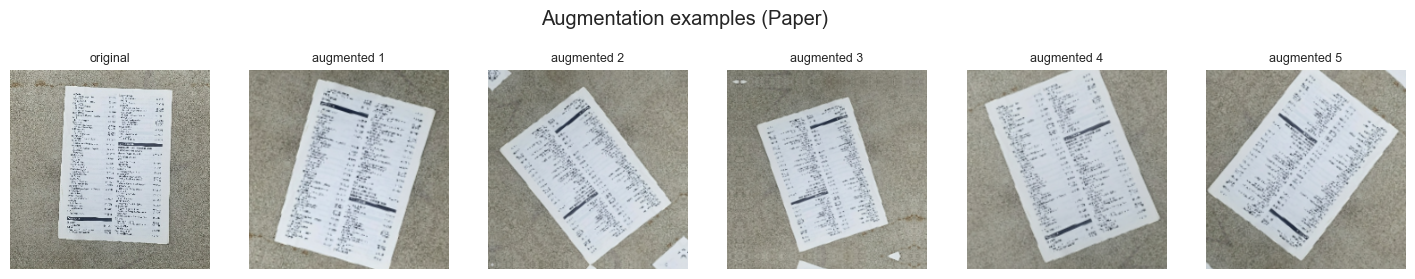

In [16]:
def make_augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
    ], name="augmentation")

demo_aug = make_augmentation()
sample_img, sample_lbl = load_image(tf.constant(train_p[0]), train_y[0])
fig, axes = plt.subplots(1, 6, figsize=(18, 3.3))
for i, ax in enumerate(axes):
    out = sample_img if i == 0 else demo_aug(sample_img[None], training=True)[0]
    ax.imshow(np.clip(out.numpy() / 255.0, 0, 1))
    ax.set_title("original" if i == 0 else f"augmented {i}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Augmentation examples ({class_names[sample_lbl]})")
plt.show()

### 2.2 Handling Class Imbalance: Class Weights

`compute_class_weight("balanced")` gives each class a weight inversely proportional to its frequency in the **training** split. In the loss function, a mistake on a rare class such as Textile Trash then costs more than a mistake on Plastic. This counteracts the pull toward majority classes without discarding or duplicating any data.

In [17]:
cw = compute_class_weight("balanced", classes=np.arange(len(class_names)), y=np.array(train_y))
class_weight = dict(enumerate(cw))
display(pd.DataFrame({"train images": split_table.loc[class_names, "train"].values,
                      "class weight": np.round(cw, 3)}, index=class_names))

,train images,class weight
Cardboard,323,1.144
Food Organics,288,1.283
Glass,294,1.257
Metal,553,0.668
Miscellaneous Trash,346,1.068
Paper,350,1.056
Plastic,645,0.573
Textile Trash,222,1.665
Vegetation,305,1.212


### 2.3 Model Builder: Transfer Learning with a Configurable Head

**Base model choice.** EfficientNetB0 is the primary candidate. It reaches strong ImageNet accuracy with only about 4M parameters, using compound scaling of depth, width and resolution. That size suits a CPU training budget and a lightweight assistant that could run on a phone. MobileNetV2 is included as a comparison because it is the standard mobile-first alternative.

**Preprocessing per base model.** This is the key fix from the original notebook:

- **EfficientNetB0** includes its own `Rescaling` and `Normalization` layers, so it receives raw 0–255 pixels.
- **MobileNetV2** expects inputs in [-1, 1], so we add `Rescaling(1/127.5, offset=-1)`.

**Head.** Global average pooling → Dropout → Dense(ReLU, L2 penalty) → [optional second Dense] → Dropout → Softmax over 9 classes. Dropout and L2 are the regularisers the brief asks for. `dense_units` and `extra_dense` control the width and depth of the custom layers.

**Loss and metric.** Sparse categorical cross-entropy, because labels are integers, with accuracy tracked during training. Macro-F1 is reported at evaluation because it weights every class equally.

The base model is called with `training=False`, so its BatchNorm layers stay in inference mode even when we unfreeze layers later. This prevents fine-tuning from corrupting the ImageNet statistics.

In [18]:
def build_cnn(base_name="efficientnetb0", dense_units=256, dropout=0.3, l2=1e-4,
              extra_dense=0, lr=1e-3):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image")
    x = make_augmentation()(inputs)
    if base_name == "efficientnetb0":
        base = keras.applications.EfficientNetB0(include_top=False, weights="imagenet",
                                                 input_shape=(*IMG_SIZE, 3))
        # EfficientNet rescales internally -> feed raw 0-255 pixels
    elif base_name == "mobilenetv2":
        base = keras.applications.MobileNetV2(include_top=False, weights="imagenet",
                                              input_shape=(*IMG_SIZE, 3))
        x = layers.Rescaling(1 / 127.5, offset=-1, name="to_minus1_1")(x)
    else:
        raise ValueError(base_name)
    base.trainable = False
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2))(x)
    if extra_dense:
        x = layers.Dropout(dropout)(x)
        x = layers.Dense(extra_dense, activation="relu",
                         kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(len(class_names), activation="softmax", name="class_probs")(x)
    model = keras.Model(inputs, outputs, name=f"{base_name}_head{dense_units}")
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model, base

### 2.4 Architecture and Hyperparameter Experiments

We compare four configurations with a frozen base for `EXP_EPOCHS` epochs each. The experiments vary:

- **width** (256 vs. 512 units),
- **depth** (one vs. two dense layers),
- **regularisation strength** (dropout 0.3 vs. 0.5),
- **base model** (EfficientNetB0 vs. MobileNetV2).

The selection criterion is **best validation accuracy**. The test set is never used for choosing. We also record the train–validation gap as an overfitting indicator.

In [19]:
cnn_experiments = [
    dict(name="EffB0 | 256 | drop 0.3", base_name="efficientnetb0", dense_units=256, dropout=0.3),
    dict(name="EffB0 | 512 | drop 0.5", base_name="efficientnetb0", dense_units=512, dropout=0.5),
    dict(name="EffB0 | 256+128 | drop 0.3", base_name="efficientnetb0", dense_units=256,
         dropout=0.3, extra_dense=128),
    dict(name="MobileNetV2 | 256 | drop 0.3", base_name="mobilenetv2", dense_units=256, dropout=0.3),
]

exp_rows = []
for cfg in cnn_experiments:
    keras.backend.clear_session()
    set_seeds()
    params = {k: v for k, v in cfg.items() if k != "name"}
    m, _ = build_cnn(**params)
    t0 = time.time()
    h = m.fit(train_ds, validation_data=val_ds, epochs=EXP_EPOCHS,
              class_weight=class_weight, verbose=1)
    best_ep = int(np.argmax(h.history["val_accuracy"]))
    exp_rows.append({
        "config": cfg["name"],
        "best_val_acc": h.history["val_accuracy"][best_ep],
        "train_acc_at_best": h.history["accuracy"][best_ep],
        "gap (train-val)": h.history["accuracy"][best_ep] - h.history["val_accuracy"][best_ep],
        "trainable_params": int(sum(np.prod(w.shape) for w in m.trainable_weights)),
        "minutes": (time.time() - t0) / 60,
    })
    del m
    gc.collect()

cnn_exp_df = pd.DataFrame(exp_rows).sort_values("best_val_acc", ascending=False).round(4)
display(cnn_exp_df)
best_cnn_cfg = next(c for c in cnn_experiments if c["name"] == cnn_exp_df.iloc[0]["config"])
print("Selected configuration:", best_cnn_cfg["name"])

Epoch 1/5
104/104 [==============================] - 97s 529ms/step - loss: 1.0675 - accuracy: 0.6088 - val_loss: 0.6974 - val_accuracy: 0.7602
Epoch 2/5
104/104 [==============================] - 48s 465ms/step - loss: 0.6706 - accuracy: 0.7622 - val_loss: 0.6023 - val_accuracy: 0.8093
Epoch 3/5
104/104 [==============================] - 49s 466ms/step - loss: 0.5472 - accuracy: 0.8097 - val_loss: 0.5458 - val_accuracy: 0.8205
Epoch 4/5
104/104 [==============================] - 49s 469ms/step - loss: 0.4942 - accuracy: 0.8268 - val_loss: 0.5188 - val_accuracy: 0.8443
Epoch 5/5
104/104 [==============================] - 49s 473ms/step - loss: 0.4501 - accuracy: 0.8461 - val_loss: 0.5233 - val_accuracy: 0.8401
Epoch 1/5
104/104 [==============================] - 73s 550ms/step - loss: 1.2470 - accuracy: 0.5670 - val_loss: 0.7476 - val_accuracy: 0.7588
Epoch 2/5
104/104 [==============================] - 51s 488ms/step - loss: 0.8183 - accuracy: 0.7261 - val_loss: 0.6656 - val_accuracy:

,config,best_val_acc,train_acc_at_best,gap (train-val),trainable_params,minutes
0,EffB0 | 256 | drop 0.3,0.8443,0.8268,-0.0175,330249,4.8864
1,EffB0 | 512 | drop 0.5,0.8303,0.7965,-0.0338,660489,4.6592
2,EffB0 | 256+128 | drop 0.3,0.8205,0.7913,-0.0291,361993,4.7220
3,MobileNetV2 | 256 | drop 0.3,0.7518,0.7453,-0.0064,330249,3.3978


Selected configuration: EffB0 | 256 | drop 0.3


### 2.5 Train the Selected Head

We rebuild the winning configuration and train it longer, with two callbacks:

- **EarlyStopping** on validation loss (patience 4, restores the best weights), which stops training once the model begins to overfit;
- **ReduceLROnPlateau** (halves the learning rate after 2 stagnant epochs), which lets the optimiser settle into a minimum.

In [20]:
keras.backend.clear_session()
set_seeds()
cnn_model, cnn_base = build_cnn(**{k: v for k, v in best_cnn_cfg.items() if k != "name"})
cnn_model.summary(line_length=100)

head_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-6),
]
hist_head = cnn_model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS,
                          class_weight=class_weight, callbacks=head_callbacks)
val_acc_head = cnn_model.evaluate(val_ds, verbose=0)[1]
print(f"Validation accuracy after head training: {val_acc_head:.4f}")

Model: "efficientnetb0_head256"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 image (InputLayer)                          [(None, 224, 224, 3)]                   0              
                                                                                                    
 augmentation (Sequential)                   (None, 224, 224, 3)                     0              
                                                                                                    
 efficientnetb0 (Functional)                 (None, 7, 7, 1280)                      4049571        
                                                                                                    
 global_average_pooling2d (GlobalAveragePoo  (None, 1280)                            0              
 ling2D)                                                   

### 2.6 Fine-tune the Top of the Base Model

Next we unfreeze the top `FINE_TUNE_LAYERS` layers of the base model, so the highest-level filters can adapt from ImageNet objects to waste materials. Three safeguards protect the pretrained weights:

- a **very low learning rate** (1e-5);
- **BatchNorm layers kept frozen**;
- **early stopping** on validation loss.

The model must be recompiled after changing `trainable` flags for the change to take effect. We keep fine-tuning only if it improves validation accuracy; otherwise we restore the head-only weights.

In [21]:
head_weights = cnn_model.get_weights()

cnn_base.trainable = True
for layer in cnn_base.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False
for layer in cnn_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
print("Trainable layers in base:", sum(l.trainable for l in cnn_base.layers))

cnn_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
n_head = len(hist_head.history["loss"])
hist_ft = cnn_model.fit(
    train_ds, validation_data=val_ds, epochs=n_head + FT_EPOCHS, initial_epoch=n_head,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5, min_lr=1e-7)])

val_acc_ft = cnn_model.evaluate(val_ds, verbose=0)[1]
print(f"Validation accuracy: head-only {val_acc_head:.4f} -> fine-tuned {val_acc_ft:.4f}")
if val_acc_ft < val_acc_head:
    cnn_model.set_weights(head_weights)
    print("Fine-tuning did not help on validation -> restored head-only weights.")

Trainable layers in base: 32
Epoch 21/30
104/104 [==============================] - 83s 662ms/step - loss: 0.2154 - accuracy: 0.9423 - val_loss: 0.4357 - val_accuracy: 0.8738 - lr: 1.0000e-05
Epoch 22/30
104/104 [==============================] - 62s 598ms/step - loss: 0.2242 - accuracy: 0.9339 - val_loss: 0.4293 - val_accuracy: 0.8738 - lr: 1.0000e-05
Epoch 23/30
104/104 [==============================] - 63s 600ms/step - loss: 0.2096 - accuracy: 0.9477 - val_loss: 0.4218 - val_accuracy: 0.8808 - lr: 1.0000e-05
Epoch 24/30
104/104 [==============================] - 63s 602ms/step - loss: 0.2085 - accuracy: 0.9477 - val_loss: 0.4214 - val_accuracy: 0.8752 - lr: 1.0000e-05
Epoch 25/30
104/104 [==============================] - 63s 603ms/step - loss: 0.2066 - accuracy: 0.9462 - val_loss: 0.4213 - val_accuracy: 0.8822 - lr: 1.0000e-05
Epoch 26/30
104/104 [==============================] - 63s 602ms/step - loss: 0.1974 - accuracy: 0.9468 - val_loss: 0.4170 - val_accuracy: 0.8836 - lr: 1.00

### 2.7 Learning Curves

These curves show the training and validation accuracy and loss across both phases. The dashed line marks where fine-tuning began.

- If validation loss rises while training loss falls, the model is overfitting.
- If both curves are flat, the model is underfitting. This is what the original notebook's curves looked like.

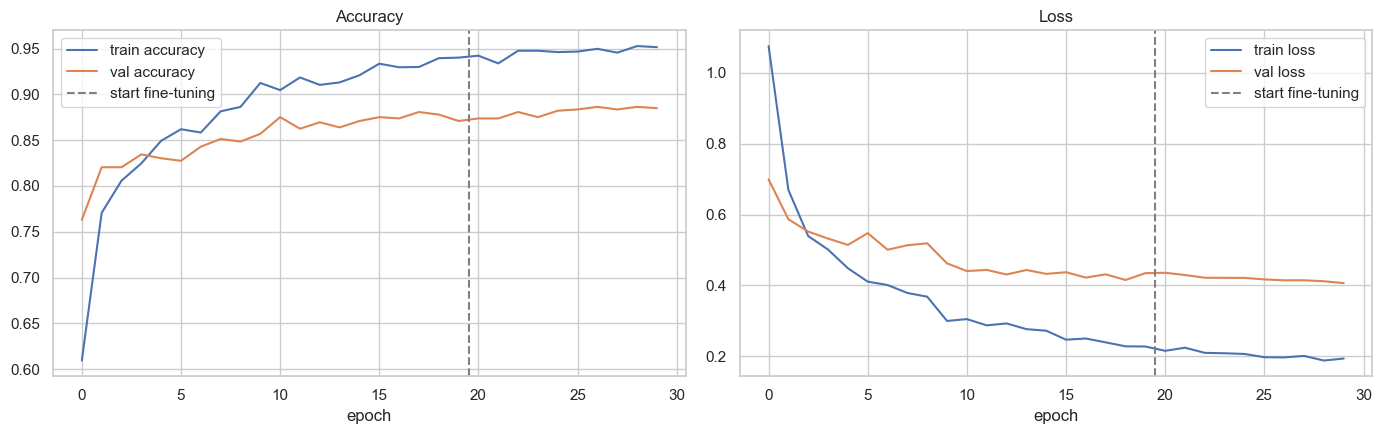

In [22]:
def merge_hist(*hs):
    out = defaultdict(list)
    for h in hs:
        for k, v in h.history.items():
            out[k].extend(v)
    return out

H = merge_hist(hist_head, hist_ft)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, key in zip(axes, ["accuracy", "loss"]):
    ax.plot(H[key], label=f"train {key}")
    ax.plot(H[f"val_{key}"], label=f"val {key}")
    ax.axvline(n_head - 0.5, ls="--", c="gray", label="start fine-tuning")
    ax.set_xlabel("epoch")
    ax.set_title(key.capitalize())
    ax.legend()
plt.tight_layout()
plt.show()

### 2.8 Test-set Evaluation

We collect **labels and predictions in the same loop**, so they are guaranteed to align. We report:

- accuracy and macro-F1;
- the per-class classification report;
- the confusion matrix, both as raw counts and row-normalised (recall per class).

CNN test accuracy: 0.8738 | macro-F1: 0.8826

                     precision    recall  f1-score   support

          Cardboard      0.800     0.928     0.859        69
      Food Organics      0.932     0.887     0.909        62
              Glass      0.800     0.825     0.812        63
              Metal      0.846     0.881     0.863       118
Miscellaneous Trash      0.896     0.800     0.845        75
              Paper      0.943     0.880     0.910        75
            Plastic      0.847     0.804     0.825       138
      Textile Trash      0.922     0.979     0.949        48
         Vegetation      0.955     0.985     0.970        65

           accuracy                          0.874       713
          macro avg      0.882     0.886     0.883       713
       weighted avg      0.876     0.874     0.874       713



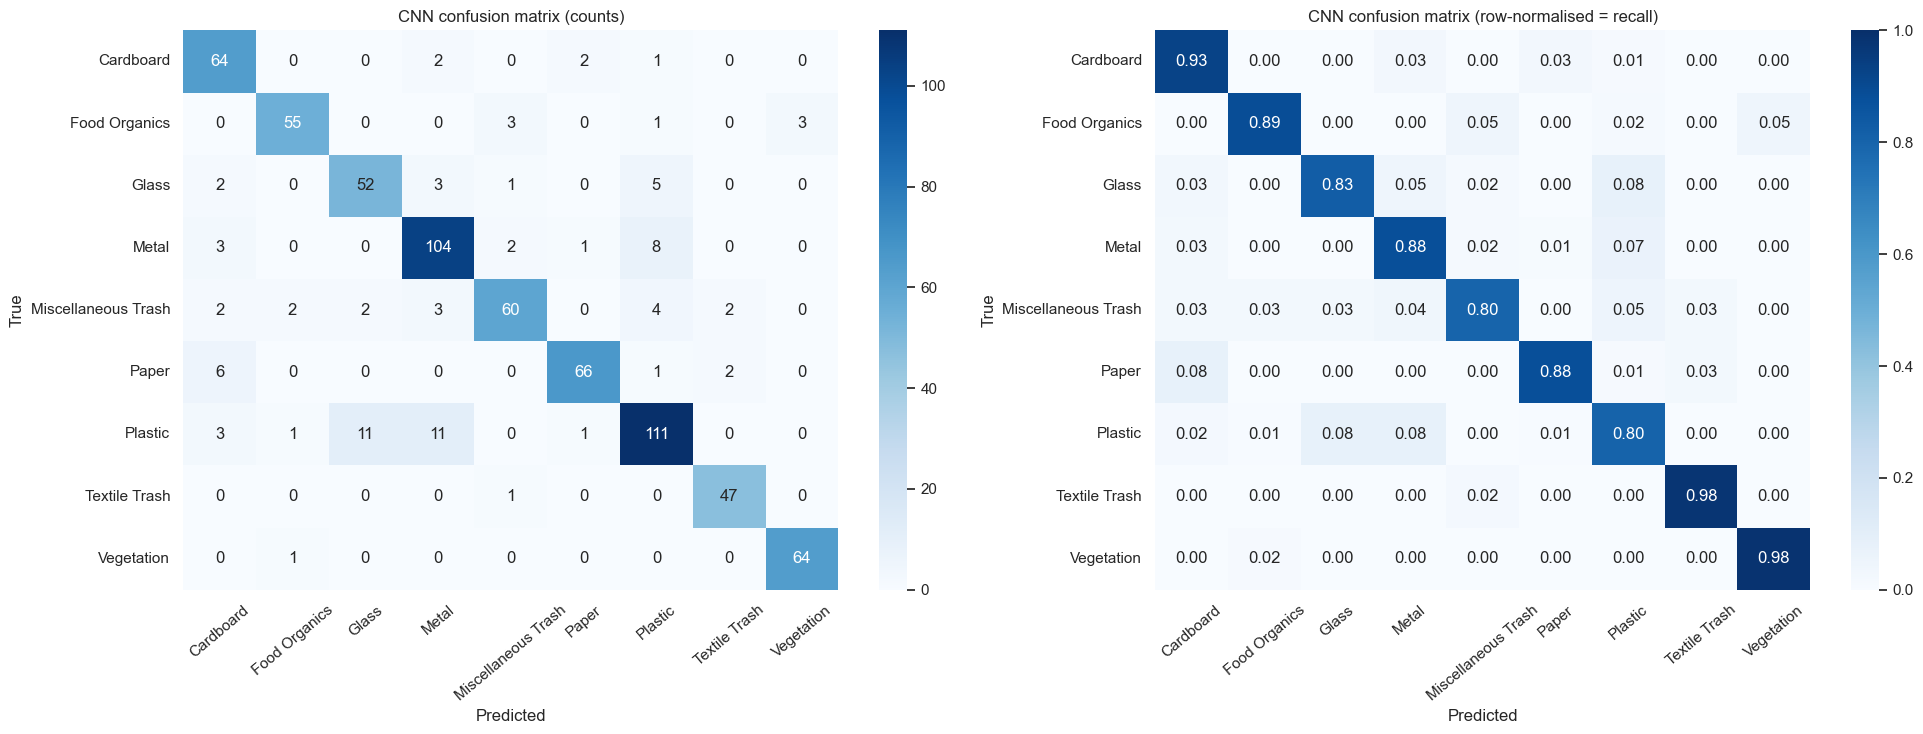

In [23]:
def predict_dataset(model, ds):
    y_true, y_prob = [], []
    for x, y in ds:
        y_prob.append(model.predict(x, verbose=0))
        y_true.append(y.numpy())
    return np.concatenate(y_true), np.concatenate(y_prob)

y_true_cnn, y_prob_cnn = predict_dataset(cnn_model, test_ds)
y_pred_cnn = y_prob_cnn.argmax(1)
cnn_test_acc = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_test_f1 = f1_score(y_true_cnn, y_pred_cnn, average="macro")
print(f"CNN test accuracy: {cnn_test_acc:.4f} | macro-F1: {cnn_test_f1:.4f}\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names, digits=3))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
cm_norm = cm_cnn / cm_cnn.sum(1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(20, 7.5))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title("CNN confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title("CNN confusion matrix (row-normalised = recall)")
for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

### 2.9 Error Pattern Analysis

We analyse the errors from four angles:

1. **Most-confused class pairs:** which specific mistakes the model makes.
2. **Per-class F1 vs. training-set size:** whether errors come from data scarcity (imbalance) or from visual similarity.
3. **Misclassified examples:** what the hard images actually look like.
4. **Confidence vs. correctness:** whether the model knows when it is unsure. This is used in Part 5 to warn users when a prediction is uncertain.

Most frequent confusions:


,true,predicted,count,share_of_true_class
26,Plastic,Metal,11,0.080
25,Plastic,Glass,11,0.080
13,Metal,Plastic,8,0.068
20,Paper,Cardboard,6,0.080
9,Glass,Plastic,5,0.079
18,Miscellaneous Trash,Plastic,4,0.053
3,Food Organics,Miscellaneous Trash,3,0.048
5,Food Organics,Vegetation,3,0.048


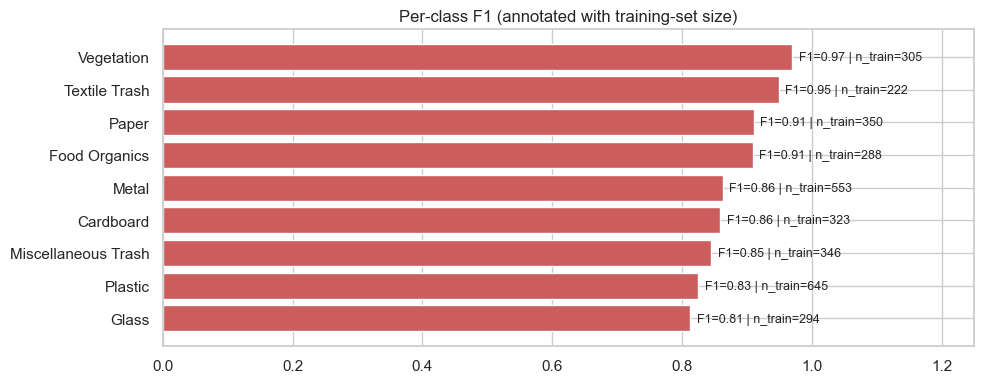

Correlation between class size and F1: -0.50


In [24]:
pairs = [(class_names[i], class_names[j], int(cm_cnn[i, j]), cm_cnn[i, j] / cm_cnn[i].sum())
         for i in range(len(class_names)) for j in range(len(class_names))
         if i != j and cm_cnn[i, j] > 0]
pairs_df = pd.DataFrame(pairs, columns=["true", "predicted", "count", "share_of_true_class"])
print("Most frequent confusions:")
display(pairs_df.sort_values("count", ascending=False).head(8).round(3))

per_class_f1 = f1_score(y_true_cnn, y_pred_cnn, average=None)
pc = pd.DataFrame({"F1": per_class_f1, "train_images": split_table.loc[class_names, "train"].values},
                  index=class_names).sort_values("F1")
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(pc.index, pc["F1"], color="indianred")
for i, (f, n) in enumerate(zip(pc["F1"], pc["train_images"])):
    ax.text(f + 0.01, i, f"F1={f:.2f} | n_train={n}", va="center", fontsize=9)
ax.set_xlim(0, 1.25)
ax.set_title("Per-class F1 (annotated with training-set size)")
plt.tight_layout()
plt.show()
print(f"Correlation between class size and F1: {np.corrcoef(pc['F1'], pc['train_images'])[0, 1]:.2f}")

Misclassified test images: 90 / 713


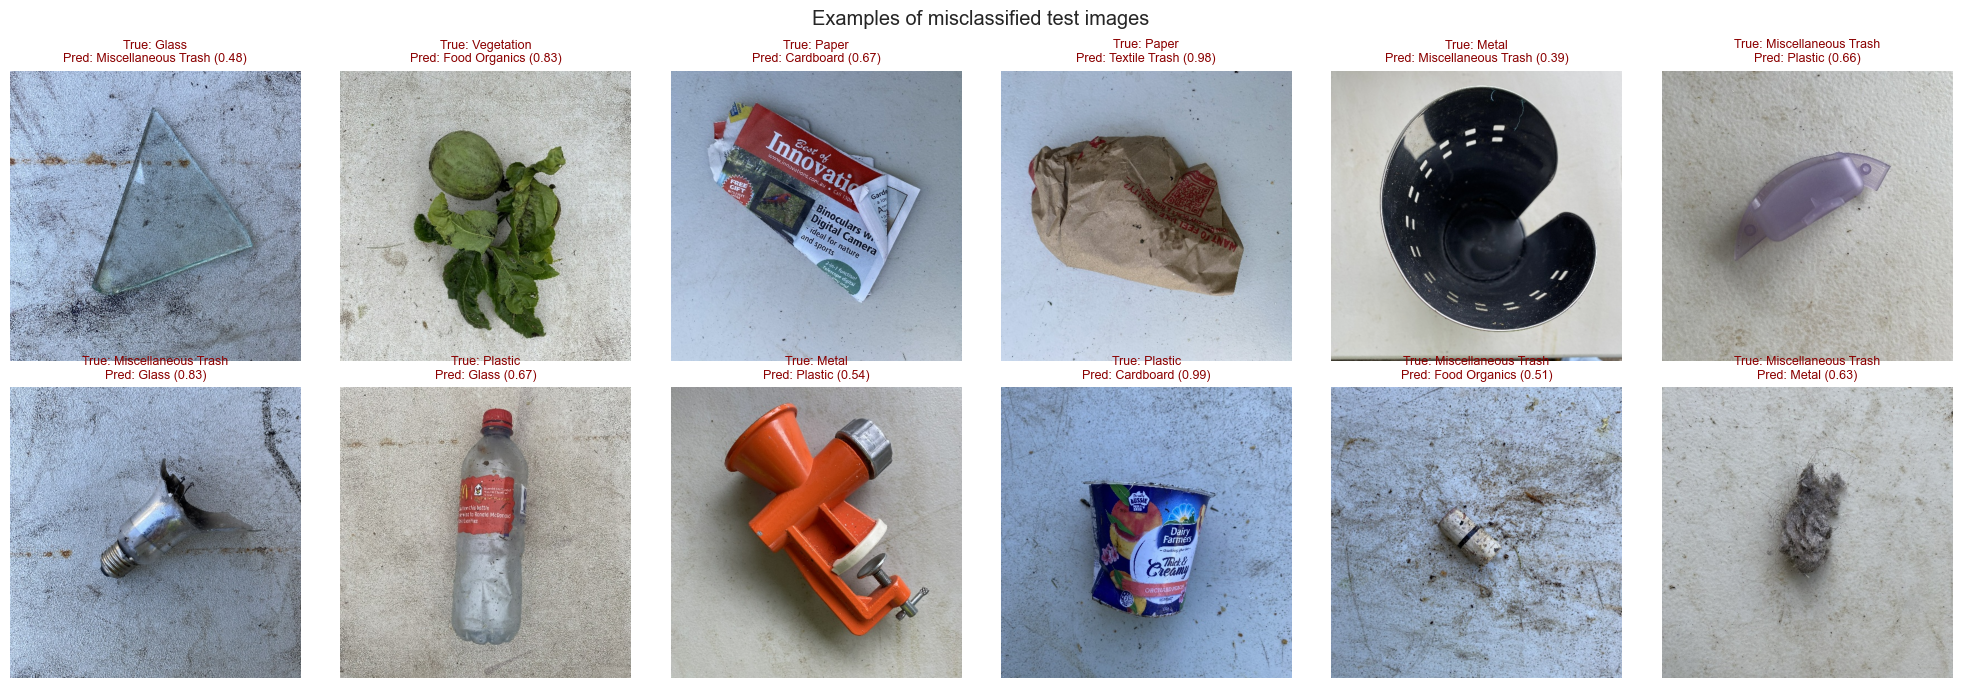

Mean confidence when correct: 0.941 | when wrong: 0.692


,threshold,coverage,accuracy_on_kept
0,0.3,1.000,0.874
1,0.4,0.990,0.878
2,0.5,0.972,0.890
3,0.6,0.928,0.906
4,0.7,0.865,0.929
5,0.8,0.825,0.951
6,0.9,0.753,0.968


Confidence threshold used by the assistant for image warnings: 0.6


In [25]:
wrong = np.where(y_pred_cnn != y_true_cnn)[0]
print(f"Misclassified test images: {len(wrong)} / {len(y_true_cnn)}")
show = np.random.RandomState(SEED).choice(wrong, size=min(12, len(wrong)), replace=False) if len(wrong) else []
if len(show):
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    for ax in axes.ravel():
        ax.axis("off")
    for ax, i in zip(axes.ravel(), show):
        with Image.open(test_p[i]) as im:
            ax.imshow(im.convert("RGB"))
        ax.set_title(f"True: {class_names[y_true_cnn[i]]}\nPred: {class_names[y_pred_cnn[i]]} "
                     f"({y_prob_cnn[i].max():.2f})", fontsize=9, color="darkred")
    plt.suptitle("Examples of misclassified test images")
    plt.tight_layout()
    plt.show()

# Confidence analysis: accuracy and coverage above each threshold
conf = y_prob_cnn.max(1)
correct = y_pred_cnn == y_true_cnn
print(f"Mean confidence when correct: {conf[correct].mean():.3f} | when wrong: {conf[~correct].mean():.3f}")
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    keep = conf >= t
    rows.append({"threshold": t, "coverage": keep.mean(),
                 "accuracy_on_kept": correct[keep].mean() if keep.any() else np.nan})
thr_df = pd.DataFrame(rows).round(3)
display(thr_df)
ok_thr = thr_df[thr_df["accuracy_on_kept"] >= 0.90]
CNN_CONF_THRESHOLD = float(ok_thr["threshold"].min()) if len(ok_thr) else 0.5
print(f"Confidence threshold used by the assistant for image warnings: {CNN_CONF_THRESHOLD}")

#### CNN: interpretation

- **Fixing the preprocessing mattered most.** Feeding raw 0–255 pixels to EfficientNetB0, with class weights and augmentation, took test accuracy from **17.9% (the original notebook) to 87.4%**. Test macro-F1 is **0.883**.
- **Model selection (2.4).** EfficientNetB0 with a 256-unit head and dropout 0.3 won (best validation accuracy **0.844**). The wider head (512 units, dropout 0.5) reached 0.830 and the deeper head (256+128) reached 0.821. Extra head capacity doesn't help on top of 1,280 pooled features and slows convergence. MobileNetV2 reached only **0.752**, about 9 points lower, which justifies EfficientNetB0 as the base. The train–validation gaps were negative in all runs, because dropout and augmentation are active only during training, so no configuration overfit in 5 epochs.
- **Fine-tuning (2.6).** Unfreezing the top 40 layers (32 trainable once BatchNorm was frozen) at LR 1e-5 raised validation accuracy from **0.871 to 0.885**. Training accuracy reached about 0.95 while validation stayed near 0.885, so a moderate generalisation gap appeared. Early stopping and the low learning rate kept it under control.
- **Challenging categories.** Glass (F1 0.812), Plastic (0.825) and Miscellaneous Trash (0.845) are the weakest. Vegetation (0.970) and Textile Trash (0.949) are the strongest. Plastic is the centre of the confusions: Plastic→Metal (11), Plastic→Glass (11), Metal→Plastic (8) and Glass→Plastic (5). This matches Part 1, where Plastic and Glass had the lowest contrast and sharpness. Transparent, reflective and crushed containers look alike. Paper→Cardboard (6) is the expected fibre-material confusion.
- **Imbalance.** The correlation between class size and F1 is **−0.50**: the largest classes (Plastic, Metal) score *lower*, not higher. Class weighting has removed the majority-class advantage. The remaining errors come from visual similarity and the high variety within Plastic, not from data scarcity.
- **Confidence (2.9).** Correct predictions average 0.941 confidence and wrong ones 0.692. At a **0.6 threshold**, the model covers 92.8% of images at 90.6% accuracy, so the assistant warns the user below 0.6. 90 of 713 test images were misclassified.
- **Possible improvements.** Targeted augmentation for transparent items (colour jitter, glare), a higher input resolution (images are natively 524 px), or EfficientNetB2.
- **Accuracy vs. speed.** MobileNetV2 trained faster in 2.4 (see the *minutes* column) and is smaller, which matters if the model runs on residents' phones. Its validation accuracy was about 9 points lower (0.752 vs. 0.844), so EfficientNetB0 is the better choice here. MobileNetV2 at a smaller input size would be the fallback option if response time on low-end devices became the priority.

## Part 3: Waste Description Classification

We use **Option B: a transformer (DistilBERT) with all layers fine-tuned**, and compare it against a TF-IDF + logistic regression baseline.

**Why DistilBERT:** it keeps about 97% of BERT's language understanding with 40% fewer parameters and runs about 60% faster. That matters for CPU training and quick responses. Its pretrained contextual embeddings capture meaning that bag-of-words features miss, such as knowing that "tin can" relates to metal. The baseline shows how much of the task is already solvable from surface word features.

### 3.1 Tokenisation and Embeddings

DistilBERT uses **WordPiece** sub-word tokenisation. Unknown or rare words are split into known pieces, e.g. "tablecloth" → "table" + "##cloth", so misspellings and regional terms still produce meaningful tokens. These tokens are mapped to DistilBERT's **pretrained contextual word embeddings** (768 dimensions), which are updated during fine-tuning. This covers the brief's "create word embeddings" step.

We choose `MAX_LEN` from the token-length distribution (99th percentile) instead of a fixed 128, because shorter padding makes training faster.

In [26]:
text_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

for s in X_train_text[:3]:
    print(f"{s!r:45} -> {text_tokenizer.tokenize(s)}")

tok_lens = [len(text_tokenizer.encode(t)) for t in X_train_text]
MAX_LEN = int(min(128, np.percentile(tok_lens, 99) + 4))
print(f"\nToken length: mean {np.mean(tok_lens):.1f}, max {max(tok_lens)} -> MAX_LEN = {MAX_LEN}")

def encode_texts(texts):
    return text_tokenizer(list(texts), truncation=True, padding="max_length",
                          max_length=MAX_LEN, return_tensors="np")

def make_text_ds(texts, labels, training, batch=16):
    enc = encode_texts(texts)
    ds = tf.data.Dataset.from_tensor_slices(
        ({"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]},
         np.asarray(labels)))
    if training:
        ds = ds.shuffle(len(labels), seed=SEED)
    return ds.batch(batch).prefetch(AUTOTUNE)

text_train_ds = make_text_ds(X_train_text, y_train_text, training=True)
text_val_ds = make_text_ds(X_val_text, y_val_text, training=False)
text_test_ds = make_text_ds(X_test_text, y_test_text, training=False)

'industrial greeting card with food residue'  -> ['industrial', 'greeting', 'card', 'with', 'food', 'residue']
'empty standard moving box'                   -> ['empty', 'standard', 'moving', 'box']
'torn oversized spotted plastic toy'          -> ['torn', 'oversized', 'spotted', 'plastic', 'toy']

Token length: mean 7.8, max 19 -> MAX_LEN = 17


### 3.2 Baseline: TF-IDF (word 1–2-grams) + Logistic Regression

This fast traditional model sets a reference point. If it already scores near 100%, the synthetic descriptions are almost linearly separable by their keywords. That is useful context for judging the transformer's score.

In [27]:
baseline = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
    LogisticRegression(max_iter=3000, C=5.0))
baseline.fit(X_train_text, y_train_text)
base_val_acc = accuracy_score(y_val_text, baseline.predict(X_val_text))
base_test_pred = baseline.predict(X_test_text)
print(f"TF-IDF + LR | val acc {base_val_acc:.4f} | test acc {accuracy_score(y_test_text, base_test_pred):.4f} "
      f"| test macro-F1 {f1_score(y_test_text, base_test_pred, average='macro'):.4f}")

TF-IDF + LR | val acc 0.9933 | test acc 0.9960 | test macro-F1 0.9961


### 3.3 DistilBERT: Fine-tuning Experiments

All DistilBERT layers are trainable: the embeddings, the 6 transformer blocks and the new classification head. We compare two learning-rate and dropout settings.

Because validation accuracy may saturate at or near 100% on this synthetic data, we select the model by **lowest validation loss**. Loss still distinguishes a confident, well-calibrated model from one that is barely right. EarlyStopping restores the best epoch.

In [28]:
def build_text_model(lr=2e-5, dropout=0.1):
    model = TFDistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=len(label2id), id2label=id2label,
        label2id=label2id, seq_classif_dropout=dropout, use_safetensors=False)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=["accuracy"])
    return model

text_experiments = [dict(lr=2e-5, dropout=0.1), dict(lr=5e-5, dropout=0.2)]
text_histories = {}
text_rows, text_model, best_val_loss = [], None, np.inf
for cfg in text_experiments:
    set_seeds()
    m = build_text_model(**cfg)
    n_trainable = sum(np.prod(w.shape) for w in m.trainable_weights)
    n_total = sum(np.prod(w.shape) for w in m.weights)
    t0 = time.time()
    h = m.fit(text_train_ds, validation_data=text_val_ds, epochs=TEXT_EPOCHS,
              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=1,
                                                       restore_best_weights=True)])
    text_histories[f"lr={cfg['lr']:.0e}, dropout={cfg['dropout']}"] = h.history
    vl = min(h.history["val_loss"])
    text_rows.append({**cfg, "best_val_loss": vl, "best_val_acc": max(h.history["val_accuracy"]),
                      "trainable/total params": f"{n_trainable:,}/{n_total:,}",
                      "minutes": (time.time() - t0) / 60})
    if vl < best_val_loss:
        best_val_loss, text_model, best_text_cfg = vl, m, cfg
    else:
        del m
    gc.collect()

text_exp_df = pd.DataFrame(text_rows)
text_exp_df["lr"] = text_exp_df["lr"].map("{:.0e}".format)   # show 2e-05, not 0.0
display(text_exp_df.round(4))
print("Selected text model:", best_text_cfg)

Epoch 1/3
217/217 [==============================] - 165s 648ms/step - loss: 0.9955 - accuracy: 0.7744 - val_loss: 0.1088 - val_accuracy: 0.9973
Epoch 2/3
217/217 [==============================] - 132s 609ms/step - loss: 0.0621 - accuracy: 0.9988 - val_loss: 0.0209 - val_accuracy: 1.0000
Epoch 3/3
217/217 [==============================] - 134s 616ms/step - loss: 0.0340 - accuracy: 0.9968 - val_loss: 0.0097 - val_accuracy: 1.0000
Epoch 1/3
217/217 [==============================] - 155s 642ms/step - loss: 0.5541 - accuracy: 0.8727 - val_loss: 0.0190 - val_accuracy: 1.0000
Epoch 2/3
217/217 [==============================] - 133s 611ms/step - loss: 0.0169 - accuracy: 0.9988 - val_loss: 0.0040 - val_accuracy: 1.0000
Epoch 3/3
217/217 [==============================] - 138s 637ms/step - loss: 0.0150 - accuracy: 0.9971 - val_loss: 0.0312 - val_accuracy: 0.9933


,lr,dropout,best_val_loss,best_val_acc,trainable/total params,minutes
0,2e-05,0.1,0.0097,1.0,"66,960,393/66,960,393",7.1799
1,5e-05,0.2,0.0040,1.0,"66,960,393/66,960,393",7.0945


Selected text model: {'lr': 5e-05, 'dropout': 0.2}


In [29]:
# Re-display the experiment table with readable learning rates (no retraining needed)
text_exp_df = pd.DataFrame(text_rows)
text_exp_df["lr"] = text_exp_df["lr"].map("{:.0e}".format)
display(text_exp_df.round(4))

,lr,dropout,best_val_loss,best_val_acc,trainable/total params,minutes
0,2e-05,0.1,0.0097,1.0,"66,960,393/66,960,393",7.1799
1,5e-05,0.2,0.0040,1.0,"66,960,393/66,960,393",7.0945


#### 3.3.1 Training Curves by Configuration

The curves show training (dashed) and validation (solid) loss and accuracy for each DistilBERT configuration. They show how quickly each learning rate converges, and whether validation loss starts rising, which would indicate overfitting. These curves support the choice of the lowest-validation-loss model above.

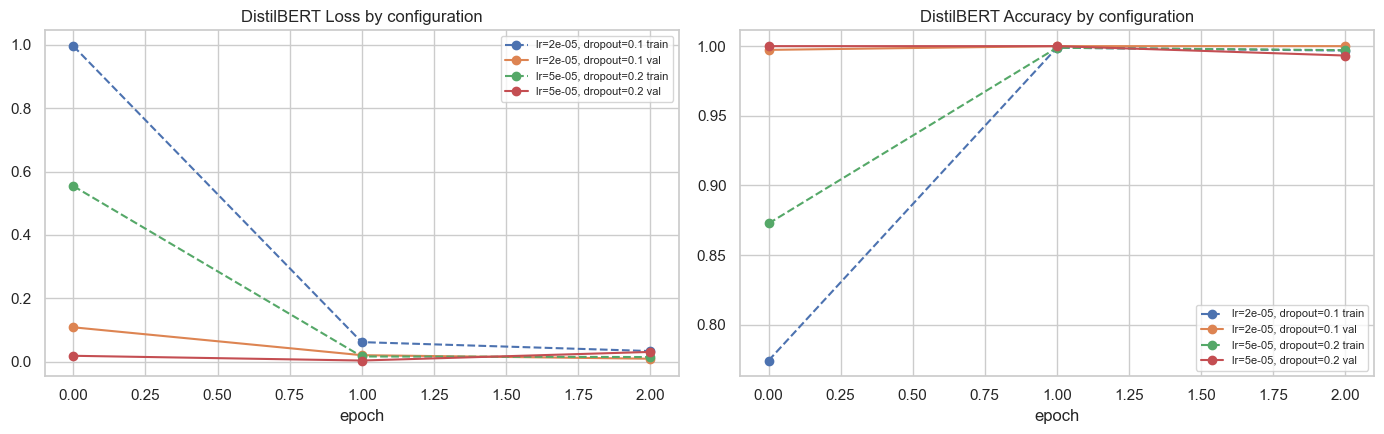

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name, hist in text_histories.items():
    for ax, key in zip(axes, ["loss", "accuracy"]):
        ax.plot(hist[key], marker="o", ls="--", label=f"{name} train")
        ax.plot(hist[f"val_{key}"], marker="o", label=f"{name} val")
for ax, key in zip(axes, ["Loss", "Accuracy"]):
    ax.set_title(f"DistilBERT {key} by configuration")
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.4 Test-set Evaluation and Comparison with the Baseline

                     precision    recall  f1-score   support

          Cardboard      1.000     1.000     1.000        87
      Food Organics      1.000     1.000     1.000        76
              Glass      1.000     1.000     1.000        81
              Metal      1.000     1.000     1.000        75
Miscellaneous Trash      1.000     1.000     1.000        87
              Paper      1.000     1.000     1.000        75
            Plastic      1.000     1.000     1.000        84
      Textile Trash      1.000     1.000     1.000        88
         Vegetation      1.000     1.000     1.000        88

           accuracy                          1.000       741
          macro avg      1.000     1.000     1.000       741
       weighted avg      1.000     1.000     1.000       741



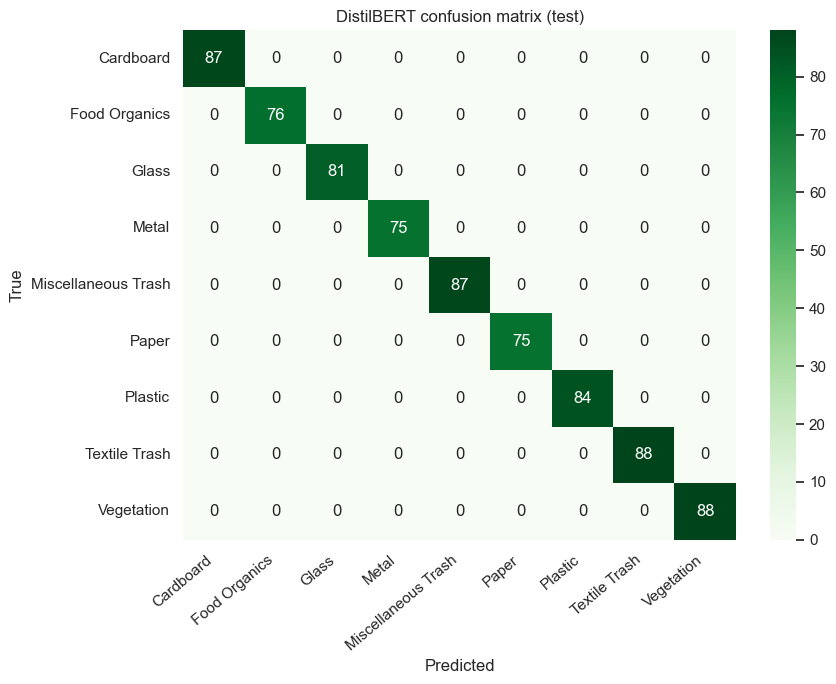

,model,test_accuracy,test_macro_F1
0,TF-IDF + LogReg,0.996,0.9961
1,DistilBERT (fine-tuned),1.000,1.0000


In [31]:
test_logits = text_model.predict(text_test_ds, verbose=0).logits
test_probs = tf.nn.softmax(test_logits, axis=-1).numpy()
y_pred_text = test_probs.argmax(1)
text_test_acc = accuracy_score(y_test_text, y_pred_text)
print(classification_report(y_test_text, y_pred_text, target_names=text_label_names, digits=3))

cm_text = confusion_matrix(y_test_text, y_pred_text)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_text, annot=True, fmt="d", cmap="Greens",
            xticklabels=text_label_names, yticklabels=text_label_names)
plt.title("DistilBERT confusion matrix (test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "model": ["TF-IDF + LogReg", "DistilBERT (fine-tuned)"],
    "test_accuracy": [accuracy_score(y_test_text, base_test_pred), text_test_acc],
    "test_macro_F1": [f1_score(y_test_text, base_test_pred, average="macro"),
                      f1_score(y_test_text, y_pred_text, average="macro")]}).round(4))

### 3.5 Error Analysis

If there are misclassifications, we list them with their confidence. If the test set is classified perfectly, we instead list the **least confident correct predictions**. These are the descriptions closest to a decision boundary and show where the model is fragile.

In [32]:
res = pd.DataFrame({"description": X_test_text,
                    "true": [id2label[i] for i in y_test_text],
                    "pred": [id2label[i] for i in y_pred_text],
                    "confidence": test_probs.max(1)})
errors = res[res["true"] != res["pred"]]
if len(errors):
    print(f"{len(errors)} misclassified test descriptions:")
    display(errors.sort_values("confidence", ascending=False).head(15))
else:
    print("No test errors. Least confident correct predictions (closest to a decision boundary):")
    display(res.sort_values("confidence").head(10))

No test errors. Least confident correct predictions (closest to a decision boundary):


,description,true,pred,confidence
506,patterned plastic ceramic mug,Miscellaneous Trash,Miscellaneous Trash,0.991178
467,red tape with contents,Miscellaneous Trash,Miscellaneous Trash,0.992162
598,dry multi-colored plastic toy,Plastic,Plastic,0.993510
12,dry brown ceramic mug with liquid inside,Miscellaneous Trash,Miscellaneous Trash,0.993793
646,wrinkled tiny green bottle cap partially filled,Metal,Metal,0.994023
62,new compact yellow rubber leather belt leaking,Textile Trash,Textile Trash,0.994069
10,ripped medium ceramic mug,Miscellaneous Trash,Miscellaneous Trash,0.994088
665,folded tiny white food container leaking,Plastic,Plastic,0.994118
417,dry bottle cap,Metal,Metal,0.994327
92,black artisanal bottle cap empty,Metal,Metal,0.994495


### 3.6 Why Is Accuracy So High? Near-duplicate Check

Exact duplicates were removed in Part 1, but templated data can still produce **near-duplicates**: the same object noun with different modifiers. For each test description, we compute its highest TF-IDF cosine similarity to any training description.

A large share of test items with similarity ≥ 0.8 means the test set mostly checks recognition of phrases the model has effectively already seen. In that case, the challenge set in 3.7 is a better estimate of real-world performance.

Test items with a near-duplicate in train (cosine >= 0.8): 19.7%
Median nearest-neighbour similarity: 0.71


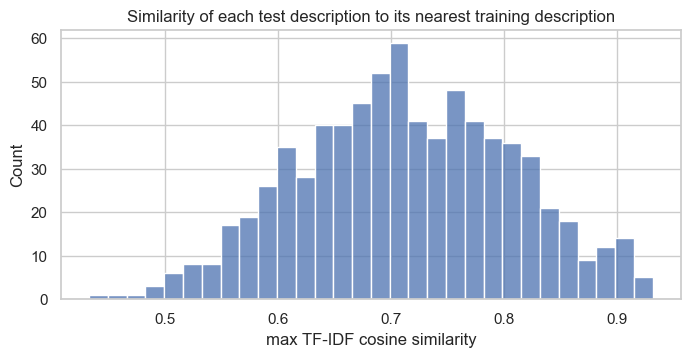

In [33]:
nn_vec = TfidfVectorizer().fit(X_train_text)
sim = nn_vec.transform(X_test_text) @ nn_vec.transform(X_train_text).T
max_sim = np.asarray(sim.max(axis=1).todense()).ravel()
print(f"Test items with a near-duplicate in train (cosine >= 0.8): {(max_sim >= 0.8).mean():.1%}")
print(f"Median nearest-neighbour similarity: {np.median(max_sim):.2f}")
plt.figure(figsize=(8, 3.5))
sns.histplot(max_sim, bins=30)
plt.title("Similarity of each test description to its nearest training description")
plt.xlabel("max TF-IDF cosine similarity")
plt.show()

### 3.7 Challenge Set: Realistic and Difficult Descriptions

Residents won't write like the template. This hand-written set tests:

- **regional terms**, such as "tin", "crisp packet", "nappy" and "rubbish";
- **typos and capitals**;
- **multi-material items**, such as a jar with a metal lid;
- **items described by use instead of material**.

The labels follow the RealWaste category of the item's main material. A few items are genuinely debatable (marked `ambiguous`) and are reported separately.

In [34]:
challenge_set = [
    ("tin can that held baked beans", "Metal", False),
    ("scrunched up aluminium foil from the roast", "Metal", False),
    ("empty jam jar with the lid still on", "Glass", True),
    ("old t-shirt full of holes", "Textile Trash", False),
    ("grass clippings and fallen leaves from the garden", "Vegetation", False),
    ("leftover rice and chicken bones", "Food Organics", False),
    ("banana peel", "Food Organics", False),
    ("newspaper and junk mail", "Paper", False),
    ("egg carton", "Cardboard", False),
    ("crisp packet", "Plastic", True),
    ("used nappy", "Miscellaneous Trash", False),
    ("broken ceramic mug", "Miscellaneous Trash", False),
    ("PET #1 soda bottle", "Plastic", False),
    ("EMPTY PLASTIK WATTER BOTLE", "Plastic", False),
    ("greasy pizza box", "Cardboard", True),
    ("wine bottle, green", "Glass", False),
]

def predict_category(text, top_k=3):
    """Classify a free-text description. Returns category, confidence and top-k alternatives."""
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Description must be a non-empty string.")
    enc = text_tokenizer([normalize_text(text)], truncation=True, padding=True,
                         max_length=MAX_LEN, return_tensors="tf")
    probs = tf.nn.softmax(text_model(enc).logits, axis=-1).numpy()[0]
    order = probs.argsort()[::-1][:top_k]
    return {"category": id2label[int(order[0])], "confidence": float(probs[order[0]]),
            "top_k": [(id2label[int(i)], float(probs[i])) for i in order]}

rows = []
for text, expected, ambiguous in challenge_set:
    p = predict_category(text)
    rows.append({"description": text, "expected": expected, "ambiguous": ambiguous,
                 "DistilBERT": p["category"], "confidence": round(p["confidence"], 3),
                 "TF-IDF+LR": id2label[int(baseline.predict([normalize_text(text)])[0])]})
chal_df = pd.DataFrame(rows)
chal_df["BERT correct"] = chal_df["DistilBERT"] == chal_df["expected"]
chal_df["LR correct"] = chal_df["TF-IDF+LR"] == chal_df["expected"]
display(chal_df)
clear = ~chal_df["ambiguous"]
print(f"Unambiguous items -> DistilBERT: {chal_df.loc[clear, 'BERT correct'].mean():.1%} | "
      f"TF-IDF+LR: {chal_df.loc[clear, 'LR correct'].mean():.1%}")

,description,expected,ambiguous,DistilBERT,confidence,TF-IDF+LR,BERT correct,LR correct
0,tin can that held baked beans,Metal,False,Metal,0.978,Metal,True,True
1,scrunched up aluminium foil from the roast,Metal,False,Metal,0.996,Metal,True,True
2,empty jam jar with the lid still on,Glass,True,Plastic,0.986,Glass,False,True
3,old t-shirt full of holes,Textile Trash,False,Textile Trash,0.997,Textile Trash,True,True
4,grass clippings and fallen leaves from the garden,Vegetation,False,Vegetation,0.997,Vegetation,True,True
5,leftover rice and chicken bones,Food Organics,False,Food Organics,0.996,Food Organics,True,True
6,banana peel,Food Organics,False,Food Organics,0.996,Food Organics,True,True
7,newspaper and junk mail,Paper,False,Paper,0.995,Paper,True,True
8,egg carton,Cardboard,False,Cardboard,0.997,Cardboard,True,True
9,crisp packet,Plastic,True,Paper,0.994,Miscellaneous Trash,False,False


Unambiguous items -> DistilBERT: 92.3% | TF-IDF+LR: 92.3%


### 3.8 Prediction Function

`predict_category(text)` was defined above. It applies the same normalisation as training and returns the predicted category, the confidence and the top-3 alternatives. The alternatives let the assistant show "did you mean …?" options when confidence is low.

In [35]:
for t in ["empty plastic water bottle", "flattened cereal box", "rusty old paint tin"]:
    print(f"{t!r:32} -> {predict_category(t)}")

'empty plastic water bottle'     -> {'category': 'Plastic', 'confidence': 0.9953182339668274, 'top_k': [('Plastic', 0.9953182339668274), ('Glass', 0.001094019622541964), ('Miscellaneous Trash', 0.0009164916118606925)]}
'flattened cereal box'           -> {'category': 'Cardboard', 'confidence': 0.9967879056930542, 'top_k': [('Cardboard', 0.9967879056930542), ('Plastic', 0.0006686041015200317), ('Miscellaneous Trash', 0.0005814899341203272)]}
'rusty old paint tin'            -> {'category': 'Metal', 'confidence': 0.9952672719955444, 'top_k': [('Metal', 0.9952672719955444), ('Miscellaneous Trash', 0.000981622957624495), ('Plastic', 0.0009716450585983694)]}


#### Text classifier: interpretation

- **Results.** The fine-tuned DistilBERT scored **100% test accuracy and macro-F1 1.000**. The TF-IDF + logistic regression baseline scored **99.6%** (macro-F1 0.996). Both DistilBERT configurations reached 100% validation accuracy, so the model was selected by validation loss (lr 5e-5 and dropout 0.2 gave 0.0040, vs. 0.0097 for lr 2e-5 and dropout 0.1). All **66,960,393** parameters were fine-tuned, as the brief requires. `MAX_LEN` was set to 17 tokens (mean 7.8), which keeps training fast.
- **Why so high.** The strong baseline shows the synthetic descriptions are almost keyword-separable (305-word vocabulary). **19.7%** of test items have a near-duplicate in training (cosine ≥ 0.8), and the median nearest-neighbour similarity is 0.71. The test set mostly measures recognition of very familiar phrasing.
- **Hardest test items.** Even the least confident correct predictions scored at least 0.991. They involve mixed-material words: "patterned plastic ceramic mug" (Miscellaneous Trash), "rubber leather belt" (Textile Trash), "bottle cap" (Metal).
- **Challenge set (the realistic test).** Both models got **12 of 13 unambiguous items right (92.3%)**, so DistilBERT's pretrained knowledge gave no advantage over TF-IDF here. Failures:
  - *Typos:* "EMPTY PLASTIK WATTER BOTLE" → Miscellaneous Trash at **0.985** confidence. WordPiece splits the misspelt words into unfamiliar pieces, and the only familiar word left, "empty", appears in every category.
  - *Regional term:* "crisp packet" → Paper at 0.994 (ambiguous item; expected Plastic film).
  - *Multi-material:* "jam jar with the lid still on" → Plastic at 0.986 (ambiguous; expected Glass).
- **Over-confidence.** Every error was made with confidence above 0.98, so softmax confidence cannot flag unfamiliar input on its own. The assistant therefore adds an **out-of-distribution check** (5.3) based on similarity to the training data. The feedback loop (5.8) turns resident corrections, such as "crisp packet → Plastic", into new training rows.
- **Limitation.** The training data lacks residents' real vocabulary, regional terms and typos. Adding augmented misspellings and regional synonyms is the main next step.

## Part 4: Recycling Instruction Generation with RAG

**Pipeline:** query + category → **retrieve** relevant policy and disposal chunks (sentence-transformer embeddings + FAISS) → **generate** instructions with Flan-T5 conditioned on those chunks → **verify** each generated sentence against the retrieved text, falling back to extractive policy text if verification fails.

### 4.1 Embeddings and Retrieval Index

- **Embedding model:** `all-MiniLM-L6-v2`, a compact sentence-transformer (384 dimensions) trained for semantic similarity. It is fast on a CPU and strong for short passages.
- **Metadata-enriched embedding text:** each chunk is embedded as `"<categories> | <title> | <section>: <text>"`. The category and section words make it easier to match queries like "how do I prepare glass?".
- **Cosine similarity:** embeddings are L2-normalised and stored in `faiss.IndexFlatIP`, so the inner product equals cosine similarity. That is the metric MiniLM was trained with. Exact (flat) search is appropriate for a small corpus.

We also build two comparison retrievers for the benchmark in 4.2: MiniLM on the plain chunk text, and a TF-IDF keyword retriever.

In [36]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def chunk_embedding_text(ch):
    return f"{', '.join(ch['categories'])} | {ch['title']} | {ch['section']}: {ch['body']}"

def build_dense_index(texts):
    emb = embedder.encode(texts, convert_to_numpy=True, normalize_embeddings=True,
                          show_progress_bar=False).astype("float32")
    idx = faiss.IndexFlatIP(emb.shape[1])
    idx.add(emb)
    return idx

rag_index = build_dense_index([chunk_embedding_text(c) for c in rag_chunks])       # final
plain_index = build_dense_index([c["text"] for c in rag_chunks])                      # ablation
tfidf_ret = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, stop_words="english")
chunk_tfidf = tfidf_ret.fit_transform([chunk_embedding_text(c) for c in rag_chunks])
print(f"FAISS index: {rag_index.ntotal} vectors of dim {rag_index.d}")

def dense_search(query, index, k):
    q = embedder.encode([query], normalize_embeddings=True).astype("float32")
    scores, ids = index.search(q, min(k, index.ntotal))
    return [(int(i), float(s)) for i, s in zip(ids[0], scores[0]) if i != -1]

def tfidf_search(query, k):
    s = (tfidf_ret.transform([query]) @ chunk_tfidf.T).toarray().ravel()
    ids = np.argsort(-s)[:k]
    return [(int(i), float(s[i])) for i in ids]

FAISS index: 85 vectors of dim 384


### 4.2 Retrieval Benchmark

We measure how often the retriever finds a chunk that belongs to the right category, **without** any category filter. Relevance means the chunk's category list contains the target category. The metrics are:

- **Hit@1** (top result relevant), **Hit@3** (any of the top 3 relevant), and **MRR** (mean reciprocal rank of the first relevant chunk).

The original notebook's Precision@3 capped at 0.33, because there was only one chunk per category, so it was misleading. Hit@k and MRR don't have that ceiling.

We use two query types:

- **Category queries** such as "How to recycle Glass", which name the category.
- **Item queries** such as "How do I dispose of *folded glass bottle leaking*?", built from held-out test descriptions. These are harder because the category isn't named.

In [37]:
query_templates = ["How to recycle {c}", "Where do I put {cl} waste?",
                   "What are the rules for disposing of {cl}?", "Can {cl} go in the recycling bin?"]
bench = []
for c in class_names:
    for t in query_templates:
        bench.append(("category query", t.format(c=c, cl=c.lower()), c))
    for d in test_df_text[test_df_text["category"] == c]["description"].sample(5, random_state=SEED):
        bench.append(("item query", f"How do I dispose of {d}?", c))

retrievers = {
    "MiniLM + metadata (final)": lambda q, k: dense_search(q, rag_index, k),
    "MiniLM plain text": lambda q, k: dense_search(q, plain_index, k),
    "TF-IDF keywords": tfidf_search,
}
rows = []
for name, fn in retrievers.items():
    for qtype, q, c in bench:
        hits = fn(q, 10)
        rel = [c in rag_chunks[i]["categories"] for i, _ in hits]
        first = next((r + 1 for r, v in enumerate(rel) if v), None)
        rows.append({"retriever": name, "query type": qtype, "Hit@1": rel[0],
                     "Hit@3": any(rel[:3]), "MRR": 1 / first if first else 0.0})
ret_df = pd.DataFrame(rows)
display(ret_df.groupby(["retriever", "query type"])[["Hit@1", "Hit@3", "MRR"]].mean().round(3).unstack())

Hit@1                     Hit@3             \
query type                category query item query category query item query   
retriever                                                                       
MiniLM + metadata (final)          1.000      0.600            1.0      0.800   
MiniLM plain text                  1.000      0.622            1.0      0.733   
TF-IDF keywords                    0.944      0.444            1.0      0.556   

                                     MRR             
query type                category query item query  
retriever                                            
MiniLM + metadata (final)          1.000      0.704  
MiniLM plain text                  1.000      0.712  
TF-IDF keywords                    0.963      0.534

### 4.3 Final Retrieval Function (Category-filtered)

In the assistant, the classifier already tells us the category. So `retrieve()`:

- **filters** to chunks tagged with that category, plus General chunks;
- ranks category-specific chunks first, then by similarity.

This is the main safeguard against the original notebook's failure, where Glass and Metal text was fed into Plastic prompts and the generator copied "recycled endlessly" from the Glass policy. Without a category, the function falls back to unfiltered semantic search.

In [38]:
def retrieve(query, category=None, k=3):
    hits = dense_search(query, rag_index, rag_index.ntotal)
    out = []
    for i, s in hits:
        ch = rag_chunks[i]
        if category is None or category in ch["categories"] or "General" in ch["categories"]:
            out.append({**ch, "score": s})
    if category:
        out.sort(key=lambda d: (category not in d["categories"], -d["score"]))
    return out[:k]

for d in retrieve("How to recycle Glass", category="Glass"):
    print(f"{d['score']:.3f} | {d['source']} | {d['section']} | {d['body'][:80]}...")

0.729 | Glass Recycling Guidelines | Preparation Instructions | Preparation Instructions: Rinse containers; Remove caps and lids (recycle separa...
0.652 | Glass Recycling Guidelines | Benefits | Benefits: Glass is 100% recyclable and can be recycled endlessly without loss of...
0.650 | Glass Resident Disposal Instructions | Resident disposal instructions | Resident disposal instructions for Glass: Remove caps, lids, and corks before re...


### 4.4 Generator, Prompt and Evaluation Metrics

**Model:** `google/flan-t5-small` (77M parameters). This instruction-tuned encoder–decoder follows "answer using the context" prompts reasonably well for its size and is small enough to fine-tune on a CPU.

**Prompt design:** the instruction and question come **first** and the context comes **last**. If the prompt exceeds `MAX_SRC_LEN`, truncation then removes the end of the context rather than the instruction. Each chunk is capped at 100 words and labelled with its source and section.

**Evaluation metrics:**

| Metric | What it measures |
|---|---|
| **ROUGE-L F1** vs. a reference answer | Content overlap with the correct policy instructions |
| **Grounding** | Share of the generation's content words found in the **same-category** retrieved chunks. The original score used all retrieved chunks, so it gave 1.00 to a sentence copied from the Glass policy. |
| **Leakage** | Share of content words found **only** in other categories' documents. This directly measures wrong-category facts. |
| **Flesch Reading Ease** | Human readability (60+ is plain English) |
| **Distinct-2** | Share of unique bigrams (low values mean repetitive text) |
| **Imperative** | Whether the text contains action instructions ("rinse", "place", …) |

The **reference answer** for a category is the resident disposal instruction plus the policy's *Collection Method* and *Preparation Instructions* sections.

In [39]:
gen_tokenizer = T5Tokenizer.from_pretrained(GEN_MODEL_NAME)
gen_model = TFT5ForConditionalGeneration.from_pretrained(GEN_MODEL_NAME, use_safetensors=False)

def build_prompt(query, category, retrieved, max_words=100):
    ctx = "\n".join(f"[{i + 1}] ({d['source']} - {d['section']}) " + " ".join(d["body"].split()[:max_words])
                    for i, d in enumerate(retrieved))
    return (f"Write clear recycling instructions for a Metro City resident using only the policy "
            f"context below. Waste category: {category}. Question: {query}\nPolicy context:\n{ctx}")

def generate_text(query, category, retrieved, model=None, **gen_kwargs):
    model = model or gen_model
    enc = gen_tokenizer(build_prompt(query, category, retrieved), return_tensors="tf",
                        truncation=True, max_length=MAX_SRC_LEN)
    kwargs = {"max_new_tokens": MAX_TGT_LEN, **gen_kwargs}
    out = model.generate(**enc, **kwargs)
    return gen_tokenizer.decode(out[0], skip_special_tokens=True).strip()

def policy_sections(category, keywords=("collection", "preparation")):
    return [c for c in rag_chunks if c["doc_type"] == "policy" and category in c["categories"]
            and any(k in c["section"].lower() for k in keywords)]

def reference_answer(category, disposal_instruction=None):
    parts = []
    if disposal_instruction:
        parts.append(disposal_instruction.strip().rstrip(".") + ".")
    parts += [c["body"] for c in policy_sections(category)]
    if not parts:   # category without a dedicated policy -> resident instructions chunk
        parts = [c["body"] for c in rag_chunks if c["doc_type"] == "disposal" and category in c["categories"]]
    return " ".join(parts)

print(build_prompt("How to recycle Glass", "Glass", retrieve("How to recycle Glass", "Glass"))[:900])
print("\nREFERENCE:", reference_answer("Glass", "Remove caps, lids, and corks before recycling."))

Write clear recycling instructions for a Metro City resident using only the policy context below. Waste category: Glass. Question: How to recycle Glass
Policy context:
[1] (Glass Recycling Guidelines - Preparation Instructions) Preparation Instructions: Rinse containers; Remove caps and lids (recycle separately); Labels can remain.
[2] (Glass Recycling Guidelines - Benefits) Benefits: Glass is 100% recyclable and can be recycled endlessly without loss of quality.
[3] (Glass Resident Disposal Instructions - Resident disposal instructions) Resident disposal instructions for Glass: Remove caps, lids, and corks before recycling. Rinse container before recycling. Place in glass recycling bin, sorted by color if required. Non-container glass may require special disposal. Broken glass should be wrapped and labeled before disposal.

REFERENCE: Remove caps, lids, and corks before recycling. Collection Method: Place in dedicated glass recycling bins. Some areas require color sorting. Preparation

In [40]:
STOP = set(ENGLISH_STOP_WORDS)

def content_tokens(s):
    return {w for w in re.findall(r"[a-z0-9#]+", str(s).lower()) if w not in STOP and len(w) > 2}

CATEGORY_VOCAB = {c: set().union(*[content_tokens(ch["text"]) for ch in rag_chunks if c in ch["categories"]] or [set()])
                  for c in class_names}
GENERAL_VOCAB = set().union(*[content_tokens(ch["text"]) for ch in rag_chunks if "General" in ch["categories"]] or [set()])

def grounding_score(text, category, retrieved):
    gen = content_tokens(text)
    if not gen:
        return 0.0
    ctx = content_tokens(category)
    for d in retrieved:
        if category in d["categories"] or "General" in d["categories"]:
            ctx |= content_tokens(d["text"])
    return len(gen & ctx) / len(gen)

def leakage_score(text, category):
    gen = content_tokens(text)
    if not gen:
        return 0.0
    own = CATEGORY_VOCAB.get(category, set()) | GENERAL_VOCAB | content_tokens(category)
    others = set().union(*[v for c, v in CATEGORY_VOCAB.items() if c != category]) - own
    return len(gen & others) / len(gen)

def rouge_l_f1(pred, ref):
    a, b = re.findall(r"\w+", pred.lower()), re.findall(r"\w+", ref.lower())
    if not a or not b:
        return 0.0
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a)):
        for j in range(len(b)):
            dp[i + 1][j + 1] = dp[i][j] + 1 if a[i] == b[j] else max(dp[i][j + 1], dp[i + 1][j])
    lcs = dp[-1][-1]
    if lcs == 0:
        return 0.0
    p, r = lcs / len(a), lcs / len(b)
    return 2 * p * r / (p + r)

def _syllables(word):
    n = len(re.findall(r"[aeiouy]+", word.lower()))
    if word.lower().endswith("e") and n > 1:
        n -= 1
    return max(1, n)

def flesch_reading_ease(text):
    sents = [s for s in re.split(r"[.!?;]+", text) if s.strip()]
    words = re.findall(r"[A-Za-z]+", text)
    if not sents or not words:
        return 0.0
    return 206.835 - 1.015 * len(words) / len(sents) - 84.6 * sum(map(_syllables, words)) / len(words)

def distinct_2(text):
    w = text.lower().split()
    bigrams = list(zip(w, w[1:]))
    return len(set(bigrams)) / len(bigrams) if bigrams else 0.0

IMPERATIVE_VERBS = {"place", "rinse", "remove", "ensure", "put", "clean", "dispose", "recycle",
                    "separate", "wash", "empty", "check", "use", "avoid", "keep", "flatten",
                    "bag", "take", "drop", "compost", "donate", "look", "bundle", "break", "do"}

def has_imperative(text):
    return int(any(w in IMPERATIVE_VERBS for w in re.findall(r"[a-z]+", text.lower())))

print("Metric sanity check - the original notebook's Plastic output:")
bad_text = "Plastic is 100% recyclable and can be recycled endlessly without loss of quality."
print(f"  leakage vs Plastic = {leakage_score(bad_text, 'Plastic'):.2f} (should be > 0 if 'endlessly' only appears in other policies)")

Metric sanity check - the original notebook's Plastic output:
  leakage vs Plastic = 0.71 (should be > 0 if 'endlessly' only appears in other policies)


### 4.5 Evaluation Set and Zero-shot Baseline

The evaluation set contains, for each of the 9 categories, one category query ("How to recycle X") and two item queries built from **held-out test** descriptions: 27 queries in total. We first measure the untuned Flan-T5 with beam search. This is the baseline that fine-tuning has to beat.

In [41]:
def make_eval_items():
    items = []
    for c in class_names:
        sub = test_df_text[test_df_text["category"] == c]
        mode_instr = sub["disposal_instruction"].mode().iloc[0] if len(sub) else None
        items.append(dict(category=c, query=f"How to recycle {c}", disposal=mode_instr))
        for _, r in sub.sample(2, random_state=SEED).iterrows():
            items.append(dict(category=c, query=f"How do I dispose of {r['description']}?",
                              disposal=r["disposal_instruction"]))
    return items

eval_items = make_eval_items()

def evaluate_generator(items, model=None, label="", **gen_kwargs):
    rows = []
    for it in items:
        retrieved = retrieve(it["query"], category=it["category"], k=3)
        out = generate_text(it["query"], it["category"], retrieved, model=model, **gen_kwargs)
        ref = reference_answer(it["category"], it["disposal"])
        rows.append({"setting": label, "category": it["category"], "query": it["query"],
                     "generation": out, "rougeL": rouge_l_f1(out, ref),
                     "grounding": grounding_score(out, it["category"], retrieved),
                     "leakage": leakage_score(out, it["category"]),
                     "flesch": flesch_reading_ease(out), "distinct2": distinct_2(out),
                     "imperative": has_imperative(out), "n_words": len(out.split())})
    return pd.DataFrame(rows)

METRICS = ["rougeL", "grounding", "leakage", "flesch", "distinct2", "imperative", "n_words"]
set_seeds()
zero_shot_df = evaluate_generator(eval_items, label="zero-shot beam4", num_beams=4, early_stopping=True)
display(zero_shot_df[METRICS].mean().round(3).to_frame("zero-shot beam4").T)
display(zero_shot_df[["category", "query", "generation"]].head(6))

,rougeL,grounding,leakage,flesch,distinct2,imperative,n_words
zero-shot beam4,0.0,0.0,0.0,0.0,0.0,0.0,1.0


,category,query,generation
0,Cardboard,How to recycle Cardboard,[3]
1,Cardboard,How do I dispose of regular-sized yellow Homem...,[3]
2,Cardboard,How do I dispose of new silver food packaging ...,[3]
3,Food Organics,How to recycle Food Organics,[3]
4,Food Organics,How do I dispose of broken large Homemade frui...,[3]
5,Food Organics,How do I dispose of massive Generic leftover p...,[3]


#### 4.5.1 Zero-shot baseline with a plain prompt

The untuned model above returned only "[3]" for every query. It copied the numbered context labels from our prompt format instead of answering. That makes it an unfair baseline: fine-tuning would look better than it really is.

For a fair comparison, we re-run the **same untuned model** with a plain prompt (context, then question, then answer cue) that has no numbered labels. This cell must run **before** fine-tuning in 4.6, because fine-tuning changes `gen_model` in place.

In [42]:
def plain_prompt(query, category, retrieved):
    ctx = " ".join(d["body"] for d in retrieved)
    return f"Context: {ctx}\n\nQuestion: {query}\nAnswer with recycling instructions for {category}:"

rows = []
for it in eval_items:
    ret = retrieve(it["query"], category=it["category"], k=3)
    enc = gen_tokenizer(plain_prompt(it["query"], it["category"], ret), return_tensors="tf",
                        truncation=True, max_length=MAX_SRC_LEN)
    out = gen_tokenizer.decode(
        gen_model.generate(**enc, max_new_tokens=MAX_TGT_LEN, num_beams=4, early_stopping=True)[0],
        skip_special_tokens=True).strip()
    ref = reference_answer(it["category"], it["disposal"])
    rows.append({"setting": "zero-shot plain prompt", "category": it["category"],
                 "query": it["query"], "generation": out,
                 "rougeL": rouge_l_f1(out, ref), "grounding": grounding_score(out, it["category"], ret),
                 "leakage": leakage_score(out, it["category"]), "flesch": flesch_reading_ease(out),
                 "distinct2": distinct_2(out), "imperative": has_imperative(out),
                 "n_words": len(out.split())})
zero_shot_plain_df = pd.DataFrame(rows)
display(pd.concat([zero_shot_df, zero_shot_plain_df]).groupby("setting")[METRICS].mean().round(3))
display(zero_shot_plain_df[["category", "query", "generation"]].head(6))

,rougeL,grounding,leakage,flesch,distinct2,imperative,n_words
setting,,,,,,,
zero-shot beam4,0.000,0.000,0.000,0.000,0.00,0.000,1.000
zero-shot plain prompt,0.235,0.968,0.019,50.715,0.98,0.926,19.148


,category,query,generation
0,Cardboard,How to recycle Cardboard,"If contaminated with food, tear off contaminat..."
1,Cardboard,How do I dispose of regular-sized yellow Homem...,"If contaminated with food, tear off contaminat..."
2,Cardboard,How do I dispose of new silver food packaging ...,"If contaminated with food, tear off contaminat..."
3,Food Organics,How to recycle Food Organics,Remove all packaging; Drain excess liquids; Us...
4,Food Organics,How do I dispose of broken large Homemade frui...,Place in general waste. Keep separate from rec...
5,Food Organics,How do I dispose of massive Generic leftover p...,Remove all packaging; Drain excess liquids


### 4.6 Fine-tuning Flan-T5 for Grounded Instruction Generation

The brief asks us to fine-tune the generator. We build supervised pairs from the **training** descriptions:

- **Input:** a prompt with a varied question (category or item phrasing) plus the retrieved context for that category.
- **Target:** the reference answer (the item's disposal instruction plus the policy's collection and preparation sections).

Because the target text is present in the context, the model learns to **copy and organise facts from the retrieved documents** rather than invent them. This is exactly the RAG behaviour we want. Validation pairs come from the validation descriptions.

Implementation notes:

- Padding tokens in the labels are set to `-100`, so they are ignored by the loss.
- Compiling without a loss makes the Hugging Face model use its built-in sequence-to-sequence loss.
- EarlyStopping on validation loss prevents overfitting to the small dataset.

The results table compares **three** settings: zero-shot with our RAG prompt, zero-shot with a plain prompt (the fair baseline from 4.5.1), and fine-tuned. Improvement should be judged against the **plain-prompt** baseline.

In [43]:
QUESTION_FORMS = ["How to recycle {c}", "How do I dispose of {d}?",
                  "Where should I put {d}?", "What should I do with {d}?"]

def build_ft_pairs(df, n_per_cat, seed=SEED):
    r = random.Random(seed)
    prompts, targets = [], []
    for c in class_names:
        sub = df[df["category"] == c]
        for _, row in sub.sample(min(n_per_cat, len(sub)), random_state=seed).iterrows():
            q = r.choice(QUESTION_FORMS).format(c=c, d=row["description"])
            prompts.append(build_prompt(q, c, retrieve(q, category=c, k=3)))
            targets.append(reference_answer(c, row["disposal_instruction"]))
    return prompts, targets

ft_train_prompts, ft_train_targets = build_ft_pairs(train_df_text, N_PER_CAT_FT)
ft_val_prompts, ft_val_targets = build_ft_pairs(val_df_text, 5, seed=SEED + 1)
print(f"Fine-tuning pairs: train {len(ft_train_prompts)} | val {len(ft_val_prompts)}")
print("\nEXAMPLE PROMPT:\n", ft_train_prompts[0][:600], "\n\nEXAMPLE TARGET:\n", ft_train_targets[0])

tgt_lens = [len(gen_tokenizer.encode(t)) for t in ft_train_targets]
src_lens = [len(gen_tokenizer.encode(p)) for p in ft_train_prompts]
print(f"\nTarget tokens: 95th pct {np.percentile(tgt_lens, 95):.0f} (limit {MAX_TGT_LEN}) | "
      f"prompt tokens: 95th pct {np.percentile(src_lens, 95):.0f} (limit {MAX_SRC_LEN})")

def tokenize_pairs(prompts, targets):
    enc = gen_tokenizer(prompts, max_length=MAX_SRC_LEN, truncation=True,
                        padding="max_length", return_tensors="np")
    lab = gen_tokenizer(text_target=targets, max_length=MAX_TGT_LEN, truncation=True,
                        padding="max_length", return_tensors="np")["input_ids"]
    lab = np.where(lab == gen_tokenizer.pad_token_id, -100, lab)
    return {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"], "labels": lab}

ft_train_ds = tf.data.Dataset.from_tensor_slices(tokenize_pairs(ft_train_prompts, ft_train_targets)) \
    .shuffle(len(ft_train_prompts), seed=SEED).batch(8).prefetch(AUTOTUNE)
ft_val_ds = tf.data.Dataset.from_tensor_slices(tokenize_pairs(ft_val_prompts, ft_val_targets)) \
    .batch(8).prefetch(AUTOTUNE)

Fine-tuning pairs: train 225 | val 45

EXAMPLE PROMPT:
 Write clear recycling instructions for a Metro City resident using only the policy context below. Waste category: Cardboard. Question: How to recycle Cardboard
Policy context:
[1] (Cardboard Recycling Guidelines - Preparation Instructions) Preparation Instructions: Remove all non-cardboard packaging; Flatten boxes to save space; Keep dry and clean.
[2] (Cardboard Resident Disposal Instructions - Resident disposal instructions) Resident disposal instructions for Cardboard: If contaminated with food, tear off contaminated parts. Flatten boxes before placing in cardboard recycling. For waxed card 

EXAMPLE TARGET:
 Remove any plastic, styrofoam, or metal parts before recycling. Collection Method: Flatten and place in recycling bins or take to cardboard recycling centers. Preparation Instructions: Remove all non-cardboard packaging; Flatten boxes to save space; Keep dry and clean.

Target tokens: 95th pct 61 (limit 128) | prompt token

Epoch 1/4
29/29 [==============================] - 199s 5s/step - loss: 1.2669 - val_loss: 0.4961
Epoch 2/4
29/29 [==============================] - 132s 5s/step - loss: 0.4648 - val_loss: 0.2999
Epoch 3/4
29/29 [==============================] - 135s 5s/step - loss: 0.2922 - val_loss: 0.2151
Epoch 4/4
29/29 [==============================] - 139s 5s/step - loss: 0.2013 - val_loss: 0.1669


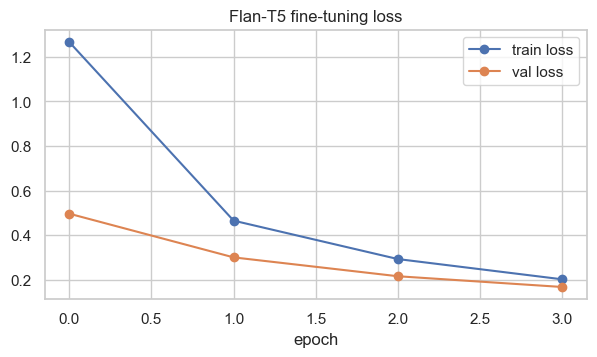

,rougeL,grounding,leakage,flesch,distinct2,imperative,n_words
setting,,,,,,,
fine-tuned beam4,0.789,0.754,0.005,42.469,0.968,0.963,32.185
zero-shot beam4,0.000,0.000,0.000,0.000,0.000,0.000,1.000
zero-shot plain prompt,0.235,0.968,0.019,50.715,0.980,0.926,19.148


,category,query,zero-shot,fine-tuned
0,Cardboard,How to recycle Cardboard,[3],Break down large boxes to save space. Collecti...
3,Food Organics,How to recycle Food Organics,[3],Keep separate from recyclable materials. Colle...
6,Glass,How to recycle Glass,[3],"Remove caps, lids, and corks before recycling...."
9,Metal,How to recycle Metal,[3],Place in metal recycling bin. Collection Metho...
12,Miscellaneous Trash,How to recycle Miscellaneous Trash,[3],Electronics should be taken to e-waste collect...
15,Paper,How to recycle Paper,[3],Ensure it is clean and dry before recycling. C...
18,Plastic,How to recycle Plastic,[3],Rinse container before recycling. Collection M...
21,Textile Trash,How to recycle Textile Trash,[3],Consider donating if still usable. Collection ...
24,Vegetation,How to recycle Vegetation,[3],Cut branches to appropriate length (usually un...


In [44]:
set_seeds()
gen_model.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-4))   # internal seq2seq loss
gen_hist = gen_model.fit(
    ft_train_ds, validation_data=ft_val_ds, epochs=GEN_EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)])

plt.figure(figsize=(7, 3.5))
plt.plot(gen_hist.history["loss"], marker="o", label="train loss")
plt.plot(gen_hist.history["val_loss"], marker="o", label="val loss")
plt.title("Flan-T5 fine-tuning loss")
plt.xlabel("epoch")
plt.legend()
plt.show()

set_seeds()
finetuned_df = evaluate_generator(eval_items, label="fine-tuned beam4", num_beams=4, early_stopping=True)
display(pd.concat([zero_shot_df, zero_shot_plain_df, finetuned_df]).groupby("setting")[METRICS].mean().round(3))

side = zero_shot_df[["category", "query", "generation"]].rename(columns={"generation": "zero-shot"})
side["fine-tuned"] = finetuned_df["generation"].values
display(side.iloc[::3].head(9))

### 4.7 Decoding Strategy Experiments

We compare decoding strategies on the fine-tuned model:

| Strategy | Settings | Expected behaviour |
|---|---|---|
| Greedy | pick the most likely token | Deterministic, can loop or repeat |
| Beam-4 | 4 beams | Fluent, conservative |
| Beam-4 + no-repeat | `no_repeat_ngram_size=3`, `repetition_penalty=1.2` | Stops repeated phrases |
| Sampling (T=0.7, top-p=0.9) | nucleus sampling, lower temperature | Some variety, moderate risk |
| Sampling (T=1.0, top-p=0.95) | more random | More varied, higher hallucination risk |

The best strategy is chosen **programmatically**, by the composite score *ROUGE-L + grounding − leakage*, which rewards being correct and grounded while penalising wrong-category content.

,rougeL,grounding,leakage,flesch,distinct2,imperative,n_words,composite
setting,,,,,,,,
sample_T0.7_p0.9,0.789,0.760,0.004,42.928,0.968,0.963,32.741,1.545
sample_T1.0_p0.95,0.794,0.753,0.008,43.451,0.981,0.963,32.000,1.540
beam4,0.789,0.754,0.005,42.469,0.968,0.963,32.185,1.538
beam4_norepeat,0.802,0.747,0.013,42.423,0.989,0.963,31.889,1.536
greedy,0.750,0.750,0.005,41.114,0.961,0.963,32.556,1.496


Selected decoding strategy: sample_T0.7_p0.9 {'do_sample': True, 'temperature': 0.7, 'top_p': 0.9, 'top_k': 50}


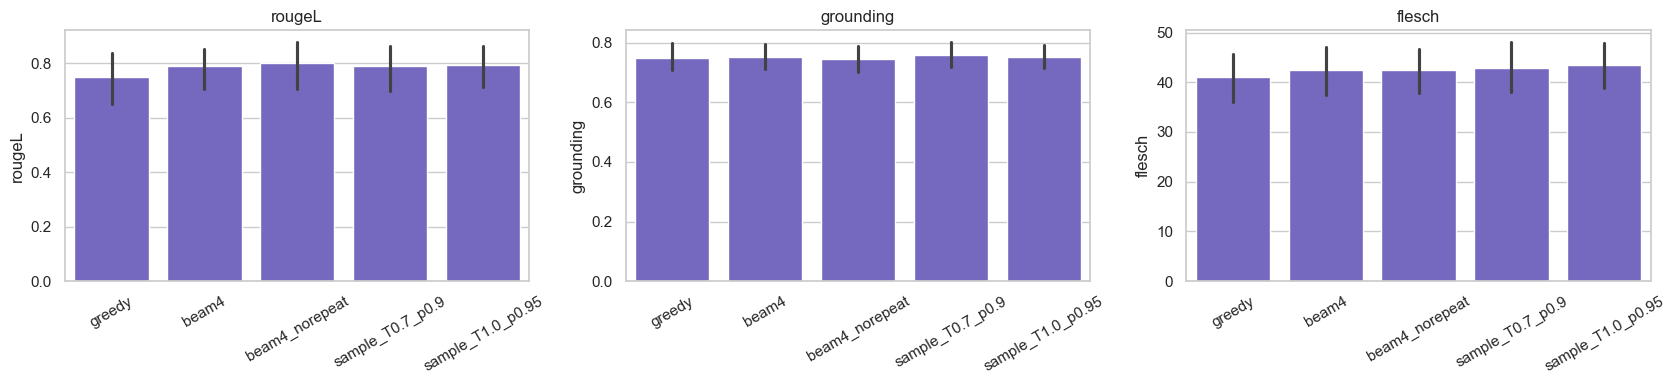

In [45]:
DECODING_STRATEGIES = {
    "greedy": dict(),
    "beam4": dict(num_beams=4, early_stopping=True),
    "beam4_norepeat": dict(num_beams=4, early_stopping=True, no_repeat_ngram_size=3, repetition_penalty=1.2),
    "sample_T0.7_p0.9": dict(do_sample=True, temperature=0.7, top_p=0.9, top_k=50),
    "sample_T1.0_p0.95": dict(do_sample=True, temperature=1.0, top_p=0.95, top_k=50),
}
dec_frames = []
for name, kw in DECODING_STRATEGIES.items():
    set_seeds()
    dec_frames.append(evaluate_generator(eval_items, label=name, **kw))
dec_df = pd.concat(dec_frames)
dec_summary = dec_df.groupby("setting")[METRICS].mean()
dec_summary["composite"] = dec_summary["rougeL"] + dec_summary["grounding"] - dec_summary["leakage"]
dec_summary = dec_summary.sort_values("composite", ascending=False).round(3)
display(dec_summary)

BEST_STRATEGY = dec_summary.index[0]
BEST_DECODING = DECODING_STRATEGIES[BEST_STRATEGY]
print("Selected decoding strategy:", BEST_STRATEGY, BEST_DECODING)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, m in zip(axes, ["rougeL", "grounding", "flesch"]):
    sns.barplot(data=dec_df, x="setting", y=m, ax=ax, color="slateblue")
    ax.set_title(m)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

### 4.8 Factual-consistency Safeguards and the Final Generation Function

A 77M-parameter model will sometimes produce text that isn't supported by the policy. `generate_instructions()` adds three safeguards:

1. **Category-filtered retrieval** (4.3), so the context contains only the right category plus General rules.
2. **Sentence-level verification.** Each generated sentence is kept only if at least 60% of its content words appear in the same-category context **and** it contains no words found exclusively in other categories' documents. Duplicate sentences are removed.
3. **Extractive fallback.** If no sentence survives, the assistant returns the relevant policy text verbatim (resident disposal instructions plus the collection and preparation sections). The resident always receives policy-accurate guidance, and the result is flagged `used_fallback=True`.

The output is formatted as bullet points for readability, and every answer returns its sources with section and effective date so residents and staff can verify it.

In [46]:
SENT_GROUNDING_MIN = 0.6

def split_sentences(text):
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

def enforce_grounding(text, category, retrieved):
    kept, dropped, seen = [], [], set()
    for s in split_sentences(text):
        key = s.lower()
        if key in seen:
            continue
        seen.add(key)
        if grounding_score(s, category, retrieved) >= SENT_GROUNDING_MIN and leakage_score(s, category) == 0:
            kept.append(s)
        else:
            dropped.append(s)
    return kept, dropped

def extractive_fallback(category, retrieved):
    preferred = [d for d in retrieved if category in d["categories"] and
                 any(k in d["section"].lower() for k in ("disposal", "collection", "preparation"))]
    chosen = (preferred or [d for d in retrieved if category in d["categories"]] or retrieved)[:2]
    return [" ".join(d["body"].split()[:60]) for d in chosen]

def format_bullets(sentences):
    lines = []
    for s in sentences:
        if ";" in s and ":" in s:
            head, rest = s.split(":", 1)
            lines.append(f"{head.strip()}:")
            lines += [f"  - {i.strip().rstrip('.')}" for i in rest.split(";") if i.strip()]
        else:
            lines.append(f"- {s}")
    return "\n".join(lines)

def generate_instructions(category, query=None, k=3, decoding=None):
    """Retrieve policy for `category`, generate instructions, verify them, and return sources."""
    if category not in CATEGORY_SET:
        raise ValueError(f"Unknown category '{category}'. Expected one of {class_names}.")
    query = query or f"How to recycle {category}"
    retrieved = retrieve(query, category=category, k=k)
    raw = generate_text(query, category, retrieved, **(decoding if decoding is not None else BEST_DECODING))
    kept, dropped = enforce_grounding(raw, category, retrieved)
    used_fallback = len(kept) == 0
    final_sents = extractive_fallback(category, retrieved) if used_fallback else kept
    final_text = " ".join(final_sents)
    return {
        "category": category, "query": query,
        "instructions": format_bullets(final_sents),
        "raw_generation": raw, "dropped_sentences": dropped, "used_fallback": used_fallback,
        "grounding": grounding_score(final_text, category, retrieved),
        "leakage": leakage_score(final_text, category),
        "sources": [{"source": d["source"], "section": d["section"],
                     "effective_date": d["effective_date"], "score": round(d["score"], 3),
                     "excerpt": " ".join(d["body"].split()[:40]) + "..."} for d in retrieved],
    }

r = generate_instructions("Glass")
print(r["instructions"])
print("\nraw:", r["raw_generation"])
print("fallback:", r["used_fallback"], "| grounding:", round(r["grounding"], 2), "| leakage:", round(r["leakage"], 2))
for s in r["sources"]:
    print("  source:", s["source"], "-", s["section"])

- Non-container glass may require special disposal.
Preparation Instructions:
  - Rinse containers
  - Remove caps and lids (recycle separately)
  - Labels can remain

raw: Non-container glass may require special disposal. Collection Method: Place in dedicated glass recycling bins. Some areas require color sorting. Preparation Instructions: Rinse containers; Remove caps and lids (recycle separately); Labels can remain.
fallback: False | grounding: 1.0 | leakage: 0.0
  source: Glass Recycling Guidelines - Preparation Instructions
  source: Glass Recycling Guidelines - Benefits
  source: Glass Resident Disposal Instructions - Resident disposal instructions


### 4.9 Final RAG Evaluation (with Safeguards)

We run the complete `generate_instructions()` pipeline over the evaluation set and report ROUGE-L, grounding, leakage, readability and the **fallback rate**. The fallback rate is the share of answers where verification rejected all generated sentences.

In [47]:
final_rows = []
for it in eval_items:
    set_seeds()
    out = generate_instructions(it["category"], it["query"])
    ref = reference_answer(it["category"], it["disposal"])
    flat = out["instructions"].replace("\n", " ")
    final_rows.append({"category": it["category"], "rougeL": rouge_l_f1(flat, ref),
                       "grounding": out["grounding"], "leakage": out["leakage"],
                       "flesch": flesch_reading_ease(flat), "imperative": has_imperative(flat),
                       "used_fallback": out["used_fallback"],
                       "n_dropped_sentences": len(out["dropped_sentences"])})
final_rag_df = pd.DataFrame(final_rows)
display(final_rag_df.drop(columns="category").mean().round(3).to_frame("final pipeline").T)
display(final_rag_df.groupby("category")[["rougeL", "grounding", "used_fallback"]].mean().round(2))

for c in ["Plastic", "Food Organics", "Textile Trash"]:
    print(f"\n=== {c} ===")
    print(generate_instructions(c)["instructions"])

,rougeL,grounding,leakage,flesch,imperative,used_fallback,n_dropped_sentences
final pipeline,0.556,0.984,0.0,36.205,1.0,0.037,1.185


,rougeL,grounding,used_fallback
category,,,
Cardboard,0.63,1.00,0.00
Food Organics,0.57,0.90,0.00
Glass,0.65,1.00,0.00
Metal,0.70,1.00,0.00
Miscellaneous Trash,0.05,1.00,0.33
Paper,0.56,1.00,0.00
Plastic,0.50,0.96,0.00
Textile Trash,0.63,1.00,0.00
Vegetation,0.71,1.00,0.00



=== Plastic ===
- Rinse container before recycling.
Preparation Instructions:
  - Rinse containers
  - Remove lids and caps (recycle separately)
  - Check for recycling codes (1-7)

=== Food Organics ===
- Use compostable bags if required.
Preparation Instructions:
  - Remove all packaging
  - Drain excess liquids
  - Use compostable bags if required

=== Textile Trash ===
- If no recycling options exist, place in general waste.
Preparation Instructions:
  - Ensure all items are clean and dry
  - Remove non-textile components when possible
  - Bag similar items together


#### RAG: interpretation

- **Corpus (1.6.3).** The retrieval index holds **85 chunks**: 67 policy sections, 9 resident-disposal chunks and 9 common-confusion chunks. Section-level tagging re-assigned **18** per-material sections (such as "METAL GUIDELINES" inside *Residential Recycling Rules*) to their single named category, so they can no longer be retrieved for the wrong category.
- **Retrieval (4.2).** Both dense retrievers find a relevant chunk first for every category query (Hit@1 = 1.000, vs. 0.944 for TF-IDF). Item queries that never name the category are much harder. Dense retrieval clearly beats keyword matching there: metadata-enriched MiniLM reaches Hit@3 **0.800** and MRR 0.704, against Hit@3 0.556 and MRR 0.534 for TF-IDF. MiniLM can link "apple core" to Food Organics without shared words. Adding metadata gave a **mixed** result: Hit@3 rose (0.800 vs. 0.733), but Hit@1 and MRR fell slightly (0.600 vs. 0.622, 0.704 vs. 0.712). We kept it because the generator uses the top 3 chunks, so Hit@3 matters most. In the assistant, the classifier's category filter removes this risk entirely.
- **Baselines (4.5, 4.5.1).** With our numbered-context prompt, the untuned Flan-T5 only output "[3]", which is a prompt-format artifact. With a plain prompt, the same untuned model gives short, well-grounded but incomplete answers: ROUGE-L **0.235**, grounding 0.968, leakage 0.019, about 19 words. This plain-prompt run is the fair baseline.
- **Fine-tuning (4.6).** Validation loss fell steadily from 0.496 to 0.167 over 4 epochs. Against the fair baseline, ROUGE-L rose from 0.235 to **0.789** (3.4×), answers grew from 19 to 32 words, and leakage fell from 0.019 to 0.005. **Grounding fell from 0.968 to 0.754.** The cause is visible in the Glass example in 4.8: the model wrote the correct *Collection Method* sentence even though that section was **not** among the three retrieved chunks. The training targets always included the collection and preparation sections, but retrieval didn't always supply them, so the model learned to recall some policy facts from memory instead of copying them from context. Those facts are correct, but not supported by the retrieved evidence, which is exactly what the verification layer in 4.8 is designed to catch.
- **Decoding (4.7).** All five strategies scored within 0.05 of each other on the composite (1.496–1.545). Nucleus sampling at T = 0.7 was selected, but only **0.007** ahead of beam-4. That difference is smaller than the variation expected from a single seed on 27 queries. The trade-offs are still visible: `beam4_norepeat` had the best ROUGE-L (0.802) but the highest leakage (0.013), and greedy had the lowest ROUGE-L (0.750). Because sampling makes answers vary between runs, **deterministic beam-4 would be the safer production choice** at practically no quality cost.
- **Safeguards (4.9).** The full pipeline reaches grounding **0.984**, leakage **0.000** and imperative wording in every answer, with a **3.7% fallback rate** (1 of 27). On average 1.19 sentences per answer were dropped by verification. This is the cost of the safeguards: ROUGE-L falls from 0.789 to **0.556**, partly because correct but unretrieved collection-method sentences are removed. Miscellaneous Trash is the weak category (ROUGE-L 0.05, fallback 33%), because its policy contains little actionable preparation text. Food Organics has the lowest grounding (0.90).
- **Readability.** Final answers score Flesch **36.2** ("difficult"), lower than the raw generations (about 42), because the extractive policy wording is formal. Bullet formatting helps, but a plain-language rewriting step would help residents more.
- **Improvements identified.** (1) Always include the category's *Collection Method* and *Preparation Instructions* sections in the context, during both fine-tuning and generation, so every training target is fully supported by its prompt. That should raise grounding and keep ROUGE-L. (2) Use beam-4 decoding for reproducible answers.
- **Limitations.** Word-overlap grounding can't detect negation or numeric errors ("do not rinse" vs. "rinse"). The corpus covers one city, so effective dates are shown with every answer.

## Part 5: Integrated Waste Management Assistant

### 5.1 Architecture

```
                 ┌──────────────────────────┐
  image  ──────▶ │ classify_image()         │──┐  category, confidence, top-3
                 │ EfficientNet CNN         │  │
                 └──────────────────────────┘  │   ┌───────────────────────────┐
                                               ├──▶│ generate_instructions()   │──▶ instructions (bulleted)
                 ┌──────────────────────────┐  │   │ retrieve (FAISS, filtered)│──▶ policy documents + dates
  text   ──────▶ │ classify_text()          │──┘   │ Flan-T5 (fine-tuned)      │──▶ grounding / fallback flags
                 │ feedback overrides →     │      │ sentence verification     │
                 │ DistilBERT               │      └───────────────────────────┘
                 └──────────────────────────┘
                              ▲                                   │
                              └────── record_feedback() ◀─────────┘  (corrections, helpfulness)
```

**Design principles**

- **One entry point**, `waste_assistant(image=… | description=…)`, which returns a single structured dictionary with a `status` field. It never raises an exception to the caller.
- **Clear component contracts.** Each classifier returns `{category, confidence, top_k}`. The generator takes `(category, query)` and returns instructions plus sources. The category vocabulary is shared by all components and checked in Part 1.
- **Stage-aware error handling.** Errors report *which* stage failed (validation, classification or generation) and the error type.
- **Uncertainty handling.** Low-confidence predictions add a warning and "did you mean" alternatives, rather than presenting a guess as fact.
- **Efficiency.** Models load once. Generation for repeated (category, question) pairs is cached, and per-stage timings are returned.
- **Feedback loop.** Corrections are logged to CSV. A text correction immediately overrides the model for that exact description and is exported as new training data.

### 5.2 Component Interfaces

`classify_image` accepts a file path, a PIL image or a NumPy array. It uses **exactly the same preprocessing as training** (`load_image`: decode, 3 channels, resize, pixels in 0–255), which avoids the original notebook's `/255` mismatch. File existence and image integrity are checked before any model call.

In [48]:
def preprocess_for_cnn(image):
    if isinstance(image, (str, pathlib.Path)):
        path = str(image)
        if not os.path.isfile(path):
            raise FileNotFoundError(f"Image not found: {path}")
        try:
            with Image.open(path) as im:
                im.verify()
        except Exception as e:
            raise ValueError(f"File is not a readable image: {path}") from e
        img, _ = load_image(tf.constant(path), 0)
    elif isinstance(image, Image.Image):
        img = tf.image.resize(np.asarray(image.convert("RGB"), dtype=np.float32), IMG_SIZE)
    elif isinstance(image, np.ndarray):
        if image.ndim != 3 or image.shape[-1] != 3:
            raise ValueError("Image array must have shape (H, W, 3).")
        img = tf.image.resize(image.astype(np.float32), IMG_SIZE)
    else:
        raise TypeError(f"Unsupported image type: {type(image).__name__}")
    return tf.expand_dims(img, 0)

def classify_image(image, top_k=3):
    probs = cnn_model.predict(preprocess_for_cnn(image), verbose=0)[0]
    order = probs.argsort()[::-1][:top_k]
    return {"category": class_names[int(order[0])], "confidence": float(probs[order[0]]),
            "top_k": [(class_names[int(i)], float(probs[i])) for i in order]}

# Feedback-driven overrides for text descriptions (filled by record_feedback)
TEXT_OVERRIDES = {}

def classify_text(description, top_k=3):
    key = normalize_text(description)
    if key in TEXT_OVERRIDES:
        return {"category": TEXT_OVERRIDES[key], "confidence": 1.0,
                "top_k": [(TEXT_OVERRIDES[key], 1.0)], "source": "feedback_override"}
    return {**predict_category(description, top_k=top_k), "source": "distilbert"}

print(classify_image(test_p[0]), "| true:", class_names[test_y[0]])
print(classify_text("flattened cardboard shipping box"))

{'category': 'Food Organics', 'confidence': 0.9927916526794434, 'top_k': [('Food Organics', 0.9927916526794434), ('Miscellaneous Trash', 0.004754312336444855), ('Vegetation', 0.0018206838285550475)]} | true: Food Organics
{'category': 'Cardboard', 'confidence': 0.9967669248580933, 'top_k': [('Cardboard', 0.9967669248580933), ('Plastic', 0.0007254656520672143), ('Miscellaneous Trash', 0.000582049717195332)], 'source': 'distilbert'}


### 5.3 Unified Assistant

The processing steps are:

1. **Validate** the input: exactly one of `image` or `description`, a non-empty description, and a length cap of 500 characters to protect the tokenizer and prompt budget.
2. **Classify** with the matching model.
3. **Check confidence.** Below the threshold, add a warning and alternatives. The image threshold comes from the confidence analysis in 2.9. For text, the classifier's confidence alone is unreliable: section 3.7 showed wrong answers at 0.98+ confidence. So we also run an **out-of-distribution check**. If a description is dissimilar to every training description (TF-IDF similarity < 0.3), or more than half its words were never seen in training, the assistant warns the resident to confirm the category.
4. **Build the query.** A resident's own question or description is passed to retrieval and generation, so their words shape the answer. The original notebook dropped them.
5. **Generate** grounded instructions, using the cache when the same request repeats.
6. **Package** the result, with the policy documents and timings.

In [49]:
TEXT_CONF_THRESHOLD = 0.6
MAX_DESC_CHARS = 500

# Out-of-distribution check for text. DistilBERT's softmax is over-confident on unfamiliar
# input (gibberish scored 0.99), so we also measure how familiar the description is.
OOD_SIM_THRESHOLD = 0.3      # max TF-IDF similarity to any training description
OOD_MAX_UNKNOWN = 0.5        # max share of words never seen in training
NN_TRAIN_MATRIX = nn_vec.transform(X_train_text)
TRAIN_ANALYZER = nn_vec.build_analyzer()

def text_familiarity(description):
    toks = TRAIN_ANALYZER(normalize_text(description))
    unknown = sum(t not in nn_vec.vocabulary_ for t in toks) / max(len(toks), 1)
    sim = float((nn_vec.transform([normalize_text(description)]) @ NN_TRAIN_MATRIX.T).max())
    return sim, unknown

@lru_cache(maxsize=256)
def _cached_generation(category, query):
    return generate_instructions(category, query)

def waste_assistant(image=None, description=None, question=None, use_cache=True):
    """Classify an image OR a text description and return grounded recycling instructions."""
    stage, timings, warnings_ = "validation", {}, []
    try:
        if image is None and description is None:
            raise ValueError("Provide either an image or a description.")
        if image is not None and description is not None:
            raise ValueError("Provide only one input: an image or a description, not both.")
        if description is not None:
            if not isinstance(description, str) or not description.strip():
                raise ValueError("Description cannot be empty.")
            if len(description) > MAX_DESC_CHARS:
                description = description[:MAX_DESC_CHARS]
                warnings_.append(f"Description truncated to {MAX_DESC_CHARS} characters.")

        stage = "classification"
        t0 = time.perf_counter()
        if image is not None:
            cls, input_type, threshold = classify_image(image), "image", CNN_CONF_THRESHOLD
            cls["source"] = "cnn"
        else:
            cls, input_type, threshold = classify_text(description), "text", TEXT_CONF_THRESHOLD
        timings["classification_ms"] = round((time.perf_counter() - t0) * 1000, 1)

        category, confidence = cls["category"], cls["confidence"]
        low_conf = confidence < threshold
        if low_conf:
            alts = ", ".join(f"{c} ({p:.0%})" for c, p in cls["top_k"])
            warnings_.append(f"Low confidence ({confidence:.0%}). Please confirm the category. Top options: {alts}.")
        if input_type == "text" and cls.get("source") != "feedback_override":
            sim, unknown = text_familiarity(description)
            if sim < OOD_SIM_THRESHOLD or unknown > OOD_MAX_UNKNOWN:
                low_conf = True
                warnings_.append(f"This description is unlike the training data (similarity {sim:.2f}, "
                                 f"{unknown:.0%} unknown words). Please confirm the category.")

        stage = "generation"
        query = question or (f"How do I dispose of {description.strip()}?" if input_type == "text"
                             else f"How to recycle {category}")
        t0 = time.perf_counter()
        gen = copy.deepcopy(_cached_generation(category, query) if use_cache
                            else generate_instructions(category, query))
        timings["generation_ms"] = round((time.perf_counter() - t0) * 1000, 1)
        if gen["used_fallback"]:
            warnings_.append("Generated text could not be verified against policy; showing policy text directly.")

        return {"status": "ok", "input_type": input_type,
                "input": description if input_type == "text" else str(image),
                "category": category, "confidence": round(confidence, 4),
                "classification_source": cls.get("source"), "top_predictions": cls["top_k"],
                "low_confidence": low_conf, "query": query,
                "instructions": gen["instructions"], "used_fallback": gen["used_fallback"],
                "grounding": round(gen["grounding"], 3), "policy_documents": gen["sources"],
                "warnings": warnings_, "timings": timings}
    except Exception as e:
        return {"status": "error", "stage": stage, "error_type": type(e).__name__,
                "error": str(e), "warnings": warnings_}

def show_result(r, show_sources=True):
    if r["status"] != "ok":
        print(f"ERROR at {r['stage']} [{r['error_type']}]: {r['error']}")
        return
    print(f"Input ({r['input_type']}): {r['input']}")
    print(f"Category: {r['category']} (confidence {r['confidence']:.2f}, via {r['classification_source']})")
    for w in r["warnings"]:
        print(f"WARNING: {w}")
    print(f"Instructions:\n{r['instructions']}")
    print(f"Grounding {r['grounding']:.2f} | fallback {r['used_fallback']} | timings {r['timings']}")
    if show_sources:
        for d in r["policy_documents"]:
            print(f"  source: {d['source']} - {d['section']} (effective {d['effective_date'] or 'n/a'}, score {d['score']})")

### 5.4 User Feedback Mechanism

`record_feedback()` captures whether the category was correct and whether the instructions helped:

- Each entry is appended to `assistant_feedback.csv`, so it persists across sessions.
- A **text correction** is stored in `TEXT_OVERRIDES` and takes effect immediately for that description.
- `feedback_summary()` shows the correction rate per predicted category. This tells the team which classes the models struggle with in real use.
- `export_text_feedback_for_retraining()` produces `(description, category)` rows that can be appended to the DistilBERT training data. **Image corrections** are logged with their file path for the next CNN retraining round.

In [50]:
FEEDBACK_FILE = "assistant_feedback.csv"
FEEDBACK_LOG = []

def record_feedback(result, correct_category=None, helpful=None, comment=""):
    if result.get("status") != "ok":
        raise ValueError("Feedback can only be recorded for successful results.")
    if correct_category is not None and correct_category not in CATEGORY_SET:
        raise ValueError(f"Unknown category '{correct_category}'.")
    entry = {"timestamp": pd.Timestamp.now().isoformat(timespec="seconds"),
             "input_type": result["input_type"], "input": result["input"],
             "predicted": result["category"], "confidence": result["confidence"],
             "correct_category": correct_category or result["category"],
             "was_correct": correct_category in (None, result["category"]),
             "helpful": helpful, "comment": comment}
    FEEDBACK_LOG.append(entry)
    pd.DataFrame([entry]).to_csv(FEEDBACK_FILE, mode="a", index=False,
                                 header=not os.path.exists(FEEDBACK_FILE))
    if result["input_type"] == "text" and correct_category and correct_category != result["category"]:
        TEXT_OVERRIDES[normalize_text(result["input"])] = correct_category
    return entry

def feedback_summary():
    if not FEEDBACK_LOG:
        return pd.DataFrame()
    fb = pd.DataFrame(FEEDBACK_LOG)
    return fb.groupby("predicted").agg(n=("was_correct", "size"),
                                       correction_rate=("was_correct", lambda s: 1 - s.mean()),
                                       helpful_rate=("helpful", lambda s: s.dropna().mean() if s.notna().any() else np.nan)).round(2)

def export_text_feedback_for_retraining():
    fb = pd.DataFrame(FEEDBACK_LOG)
    if fb.empty:
        return fb
    fb = fb[(fb["input_type"] == "text") & (~fb["was_correct"])]
    return fb.rename(columns={"input": "description", "correct_category": "category"})[["description", "category"]]

### 5.5 Standard Test Cases: Images from the Held-out Test Set

As the brief requires, we test the assistant with images **from the test split**: one randomly chosen test image per class. The table shows the true class, the prediction, the confidence, whether a warning was raised, and the end-to-end time. One full result is then shown next to its image.

,true,predicted,correct,confidence,low_conf_warning,fallback,status,total_s
0,Cardboard,Cardboard,True,1.0000,False,False,ok,6.97
1,Food Organics,Miscellaneous Trash,False,0.6272,False,False,ok,2.92
2,Glass,Glass,True,0.8844,False,False,ok,7.16
3,Metal,Metal,True,0.9984,False,False,ok,7.94
4,Miscellaneous Trash,Miscellaneous Trash,True,0.6094,False,False,ok,0.13
5,Paper,Paper,True,0.9901,False,False,ok,7.68
6,Plastic,Plastic,True,0.9972,False,False,ok,8.00
7,Textile Trash,Textile Trash,True,1.0000,False,False,ok,8.31
8,Vegetation,Vegetation,True,1.0000,False,False,ok,7.64


Assistant image accuracy on this sample: 89%


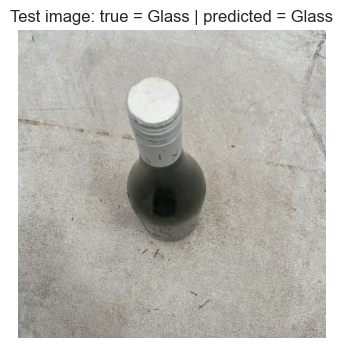

Input (image): realwaste\Glass\Glass_235.jpg
Category: Glass (confidence 0.88, via cnn)
Instructions:
- Rinse container before recycling.
Preparation Instructions:
  - Rinse containers
  - Remove caps and lids (recycle separately)
  - Labels can remain
Grounding 1.00 | fallback False | timings {'classification_ms': 157.7, 'generation_ms': 7002.7}
  source: Glass Recycling Guidelines - Preparation Instructions (effective 2023-01-24, score 0.729)
  source: Glass Recycling Guidelines - Benefits (effective 2023-01-24, score 0.652)
  source: Glass Resident Disposal Instructions - Resident disposal instructions (effective n/a, score 0.65)


In [51]:
rng = np.random.RandomState(SEED)
test_by_class = defaultdict(list)
for p, y in zip(test_p, test_y):
    test_by_class[y].append(p)

img_rows, img_results = [], {}
for y, c in enumerate(class_names):
    p = test_by_class[y][rng.randint(len(test_by_class[y]))]
    t0 = time.perf_counter()
    r = waste_assistant(image=p)
    img_results[c] = (p, r)
    img_rows.append({"true": c, "predicted": r.get("category"), "correct": r.get("category") == c,
                     "confidence": r.get("confidence"), "low_conf_warning": r.get("low_confidence"),
                     "fallback": r.get("used_fallback"), "status": r["status"],
                     "total_s": round(time.perf_counter() - t0, 2)})
img_test_df = pd.DataFrame(img_rows)
display(img_test_df)
print(f"Assistant image accuracy on this sample: {img_test_df['correct'].mean():.0%}")

p, r = img_results["Glass"]
with Image.open(p) as im:
    plt.figure(figsize=(4, 4))
    plt.imshow(im.convert("RGB"))
    plt.axis("off")
    plt.title(f"Test image: true = Glass | predicted = {r.get('category')}")
    plt.show()
show_result(r)

### 5.6 Standard Test Cases: Text Descriptions

In [52]:
for d in ["empty plastic water bottle with cap removed",
          "flattened cardboard shipping box, clean and dry",
          "clear glass jam jar with metal lid"]:
    print("=" * 90)
    show_result(waste_assistant(description=d), show_sources=False)

Input (text): empty plastic water bottle with cap removed
Category: Plastic (confidence 1.00, via distilbert)
Instructions:
- Remove labels if possible.
Preparation Instructions:
  - Rinse containers
  - Remove lids and caps (recycle separately)
  - Check for recycling codes (1-7)
Grounding 1.00 | fallback False | timings {'classification_ms': 155.8, 'generation_ms': 7242.2}
Input (text): flattened cardboard shipping box, clean and dry
Category: Cardboard (confidence 1.00, via distilbert)
Instructions:
- Flatten boxes before placing in cardboard recycling.
- Collection Method: Flatten and place in recycling bins or take to cardboard recycling centers.
Preparation Instructions:
  - Remove all non-cardboard packaging
  - Flatten boxes to save space
  - Keep dry and clean
Grounding 1.00 | fallback False | timings {'classification_ms': 111.3, 'generation_ms': 7884.5}
Input (text): clear glass jam jar with metal lid
Category: Metal (confidence 0.63, via distilbert)
Instructions:
- Place in 

### 5.6.1 End-to-end Evaluation at Scale

The standard tests above check one image per class. Here we run a larger held-out sample through the **complete assistant**: 3 test-set images and 5 test-set descriptions per class (72 requests). For each input type we report:

- end-to-end accuracy (did the resident get instructions for the right category?);
- the share of requests that returned instructions;
- warning and fallback rates, mean grounding and mean response time;
- a confusion matrix for the integrated system, and a list of misrouted requests.

Image requests reuse cached instructions per category, so they are fast. Each text request generates a new answer (about 7–8 seconds on CPU), so this cell takes roughly 6–8 minutes. It runs before the feedback demo in 5.8, so no feedback overrides affect the results.

,requests,accuracy,instructions_returned,warning_rate,fallback_rate,mean_grounding,mean_seconds
input_type,,,,,,,
image,27,0.963,1.0,0.037,0.000,0.968,0.341
text,45,1.000,1.0,0.022,0.022,0.971,6.871


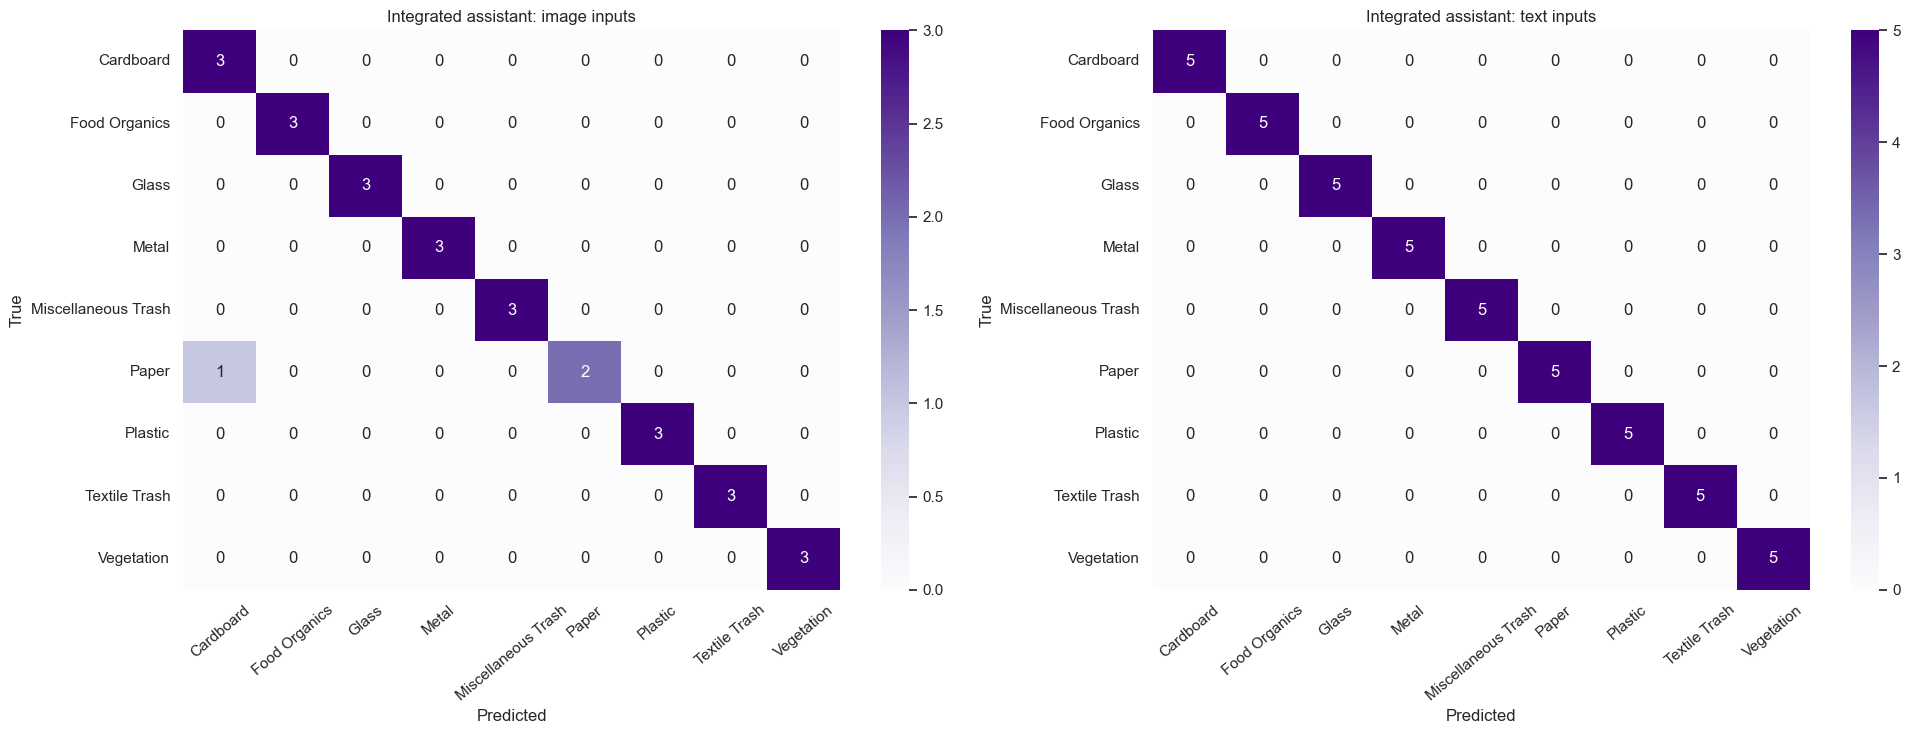

Misrouted requests: 1 | of these, carried a warning: 0%


,input_type,input,true,predicted,warning
17,image,Paper_176.jpg,Paper,Cardboard,False


In [53]:
E2E_IMAGES_PER_CLASS = 3
E2E_TEXTS_PER_CLASS = 5
e2e_rng = np.random.RandomState(SEED + 7)

def e2e_row(input_type, label, true_cat, r):
    ok = r["status"] == "ok"
    return {"input_type": input_type, "input": label, "true": true_cat,
            "predicted": r.get("category") if ok else "ERROR",
            "correct": ok and r.get("category") == true_cat,
            "instructions_returned": ok and bool(r.get("instructions")),
            "warning": ok and bool(r.get("warnings")),
            "fallback": ok and r.get("used_fallback", False),
            "grounding": r.get("grounding", np.nan),
            "seconds": sum(r.get("timings", {}).values()) / 1000}

e2e_rows = []
for y, c in enumerate(class_names):
    paths = test_by_class[y]
    for p in e2e_rng.choice(paths, size=min(E2E_IMAGES_PER_CLASS, len(paths)), replace=False):
        e2e_rows.append(e2e_row("image", pathlib.Path(p).name, c, waste_assistant(image=p)))
for c in class_names:
    sub = test_df_text[test_df_text["category"] == c]
    for d in sub["description"].sample(min(E2E_TEXTS_PER_CLASS, len(sub)), random_state=SEED + 7):
        e2e_rows.append(e2e_row("text", d, c, waste_assistant(description=d)))
e2e_df = pd.DataFrame(e2e_rows)

e2e_summary = e2e_df.groupby("input_type").agg(
    requests=("correct", "size"), accuracy=("correct", "mean"),
    instructions_returned=("instructions_returned", "mean"),
    warning_rate=("warning", "mean"), fallback_rate=("fallback", "mean"),
    mean_grounding=("grounding", "mean"), mean_seconds=("seconds", "mean")).round(3)
display(e2e_summary)

fig, axes = plt.subplots(1, 2, figsize=(20, 7.5))
for ax, t in zip(axes, ["image", "text"]):
    sub = e2e_df[(e2e_df["input_type"] == t) & (e2e_df["predicted"] != "ERROR")]
    cm = confusion_matrix(sub["true"], sub["predicted"], labels=class_names)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"Integrated assistant: {t} inputs")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

wrong_e2e = e2e_df[~e2e_df["correct"]]
print(f"Misrouted requests: {len(wrong_e2e)} | of these, carried a warning: "
      f"{wrong_e2e['warning'].mean() if len(wrong_e2e) else float('nan'):.0%}")
display(wrong_e2e[["input_type", "input", "true", "predicted", "warning"]])

**Results.**

- **Accuracy.** The assistant routed **26 of 27 test images (96.3%)** and **all 45 test descriptions (100%)** to the correct category. The image figure is higher than the CNN's test accuracy (87.4%) because the sample is small (3 per class), not because integration adds anything. The important point is that there is no integration gap: the assistant reproduces the standalone model's behaviour.
- **Instructions and grounding.** Every one of the 72 requests returned instructions, with mean grounding 0.968 (image) and 0.971 (text).
- **Response time.** Image requests averaged **0.34 s**, because their instructions are cached per category. Text requests averaged **6.9 s**, because each description triggers a new generation.
- **Warnings.** The out-of-distribution check flagged 1 of 45 in-distribution descriptions (2.2%), a low false-alarm rate. One text answer (2.2%) used the extractive fallback.
- **The single error.** *Paper_176.jpg* was predicted as Cardboard **without a warning**. Paper↔Cardboard is the fibre-material confusion identified in 2.9. The section 5.5 test showed the same weakness: a Food Organics image went to Miscellaneous Trash at 0.627, just above the 0.6 threshold. Confidence warnings catch uncertain predictions but **not confident mistakes** between similar materials. Calibration (for example temperature scaling) or asking the resident to confirm whenever the top two classes are close would be the next safeguard.

### 5.7 Edge Cases and Robustness

Each case states the expected status, and the table reports whether the assistant behaved as expected. The cases cover:

- invalid calls: no input, both inputs, an empty description, a wrong type;
- file problems: a missing file and a **corrupt** file with an image extension;
- difficult but valid inputs: non-waste gibberish (should succeed, with a low-confidence warning), an over-long description (truncated with a warning), typos and capitals, a multi-material item, and a resident's own question.

With the out-of-distribution check in 5.3, the gibberish and typo cases should now carry at least one warning. The *warnings* count in the detail column shows this.

In [54]:
with open("corrupt_test.jpg", "w") as f:
    f.write("this is not really an image")

edge_cases = [
    ("No input", {}, "error"),
    ("Both inputs", dict(image=test_p[0], description="plastic bottle"), "error"),
    ("Empty description", dict(description="   "), "error"),
    ("Wrong input type", dict(image=12345), "error"),
    ("Missing image file", dict(image="does_not_exist.jpg"), "error"),
    ("Corrupt image file", dict(image="corrupt_test.jpg"), "error"),
    ("Non-waste gibberish", dict(description="asdfgh qwerty zxcv"), "ok"),
    ("Very long description", dict(description="old plastic bottle " * 60), "ok"),
    ("Typos + capitals", dict(description="EMPTY PLASTIK WATTER BOTLE"), "ok"),
    ("Multi-material item", dict(description="glass jar with a metal lid and a paper label"), "ok"),
    ("Resident's own question", dict(description="pizza box with grease stains",
                                     question="Can I recycle a greasy pizza box?"), "ok"),
]
edge_rows = []
for name, kwargs, expected in edge_cases:
    r = waste_assistant(**kwargs)
    edge_rows.append({"case": name, "expected": expected, "status": r["status"],
                      "passed": r["status"] == expected,
                      "detail": r.get("error") if r["status"] == "error"
                                else f"{r['category']} ({r['confidence']:.2f}); warnings: {len(r['warnings'])}"})
edge_df = pd.DataFrame(edge_rows)
display(edge_df)
print(f"Edge cases passed: {edge_df['passed'].sum()}/{len(edge_df)}")
os.remove("corrupt_test.jpg")

,case,expected,status,passed,detail
0,No input,error,error,True,Provide either an image or a description.
1,Both inputs,error,error,True,Provide only one input: an image or a descript...
2,Empty description,error,error,True,Description cannot be empty.
3,Wrong input type,error,error,True,Unsupported image type: int
4,Missing image file,error,error,True,Image not found: does_not_exist.jpg
5,Corrupt image file,error,error,True,File is not a readable image: corrupt_test.jpg
6,Non-waste gibberish,ok,ok,True,Miscellaneous Trash (0.99); warnings: 1
7,Very long description,ok,ok,True,Plastic (1.00); warnings: 1
8,Typos + capitals,ok,ok,True,Miscellaneous Trash (0.98); warnings: 1
9,Multi-material item,ok,ok,True,Metal (0.99); warnings: 0


Edge cases passed: 11/11


### 5.8 Feedback Loop Demonstration

A resident describes a regional item. If the model gets it wrong, they submit a correction. The **same description** is then classified correctly through the override, and the correction appears in the retraining export. Some helpfulness feedback on the image tests is simulated to show the summary report.

In [55]:
demo_text = "crisp packet"
before = waste_assistant(description=demo_text)
print(f"Before feedback: {before['category']} ({before['confidence']:.2f}) via {before['classification_source']}")

correct = "Plastic"
record_feedback(before, correct_category=correct, helpful=before["category"] == correct,
                comment="Crisp packets are plastic film")
after = waste_assistant(description=demo_text)
print(f"After feedback : {after['category']} ({after['confidence']:.2f}) via {after['classification_source']}")

# Simulated helpfulness ratings on the image tests (for demonstration only)
for c, (p, r) in img_results.items():
    if r["status"] == "ok":
        record_feedback(r, correct_category=c, helpful=r["category"] == c)

print("\nFeedback summary by predicted category:")
display(feedback_summary())
print("Rows exported for DistilBERT retraining:")
display(export_text_feedback_for_retraining())

Before feedback: Paper (0.99) via distilbert
After feedback : Plastic (1.00) via feedback_override

Feedback summary by predicted category:


,n,correction_rate,helpful_rate
predicted,,,
Cardboard,1,0.0,1.0
Glass,1,0.0,1.0
Metal,1,0.0,1.0
Miscellaneous Trash,2,0.5,0.5
Paper,2,0.5,0.5
Plastic,1,0.0,1.0
Textile Trash,1,0.0,1.0
Vegetation,1,0.0,1.0


Rows exported for DistilBERT retraining:


,description,category
0,crisp packet,Plastic


### 5.9 Efficiency: Caching

Classification is fast, and generation dominates latency. The first call for a (category, question) pair runs retrieval and generation. A repeated call is served from the cache.

In [56]:
_cached_generation.cache_clear()
t0 = time.perf_counter(); waste_assistant(description="aluminium drink can"); first = time.perf_counter() - t0
t0 = time.perf_counter(); waste_assistant(description="aluminium drink can"); second = time.perf_counter() - t0
print(f"First call: {first:.2f}s | repeated call (cached): {second:.3f}s | speed-up x{first / max(second, 1e-6):.0f}")
print(_cached_generation.cache_info())

First call: 7.91s | repeated call (cached): 0.086s | speed-up x92
CacheInfo(hits=1, misses=1, maxsize=256, currsize=1)


## Conclusions, Limitations and Next Steps

**Headline results:** CNN test accuracy **87.4%** (macro-F1 0.883, up from 17.9% in the original notebook). Text classifier **100%** on the test set and **92.3%** on the realistic challenge set. The RAG pipeline produces answers with grounding **0.984**, **zero** wrong-category leakage and a **3.7%** fallback rate. Fine-tuning raised ROUGE-L from 0.235 (fair zero-shot baseline) to 0.789. End to end, the assistant routed **26 of 27** held-out images and **all 45** held-out descriptions correctly, passed all **11 edge cases** (the out-of-distribution check now flags gibberish and misspelt input), and serves repeated requests about 90× faster from cache.

**What was built**

- **Data:** a full-dataset image audit (resolution, lighting, sharpness, background, integrity, duplicates) and text and policy EDA. Stratified 70/15/15 splits with no overlap, and duplicate removal before splitting.
- **CNN:** EfficientNetB0 transfer learning with correct preprocessing, augmentation, class weights, width/depth/regularisation/base-model experiments, fine-tuning with frozen BatchNorm, and a full error and confidence analysis.
- **Text:** a fine-tuned DistilBERT with all layers trainable and a TF-IDF baseline, an explanation for the near-perfect test score (near-duplicate analysis), and a realistic challenge set.
- **RAG:** section-aware chunks plus resident disposal instructions, metadata-enriched cosine retrieval benchmarked against two alternatives, a Flan-T5 fine-tuned to copy from context, decoding experiments, and sentence-level grounding verification with an extractive fallback.
- **Assistant:** one validated entry point with stage-aware errors, confidence warnings, cached generation, source citations with effective dates, and a persistent feedback loop that corrects text predictions immediately and produces retraining data. It is evaluated end to end on 72 held-out requests (5.6.1) as well as 11 edge cases.

**Limitations**

1. The text data is synthetic and templated, so test accuracy overstates real-world performance. The challenge set is the more honest signal.
2. RealWaste images come from one facility. Residents' phone photos will differ in background and lighting.
3. Flan-T5-small has limited generation quality. The safeguards favour correctness, sometimes returning extractive policy text, over fluency.
4. Word-overlap grounding can't detect negation or numeric errors.
5. The policies cover a single jurisdiction and may change, so effective dates are surfaced for verification.
6. The fine-tuned generator sometimes recalls correct policy facts from memory rather than from the retrieved context. Verification removes those sentences, which protects residents but lowers completeness (ROUGE-L 0.789 raw vs. 0.556 verified).
7. Confidence warnings miss confident errors between similar materials, such as a Paper image classified as Cardboard.

**Next steps:** always include each category's collection and preparation sections in the generator's context; switch to deterministic beam-4 decoding; calibrate classifier confidence; collect real resident photos and descriptions through the feedback loop; test a larger generator such as Flan-T5-base; add an NLI-based factuality check; and add a "not sure" route that asks the resident a clarifying question for multi-material items.